In [10]:
import glob

lst = glob.glob('/home/jainv/dr_osb_lab/ChemoTask/chemoTimelines2025_test_data/**/*.xml', recursive=True)

with open(lst[0].split('.')[0], 'r') as f:
    cont = f.read()
    
print(cont)

Report ID.....................1765,6ikO3e/tMCBd
Patient ID....................6ikO3e/tMCBd
Patient Name..................Patient02
Principal Date................20110512 1622
Record Type...................DS
[Report de-identified (Limited dataset compliant) by De-ID v.6.24.5.1]


Discharge Summary/Day of DC Note
Institution

Patient:   Patient02 H            MRN:             FIN:

Age:   69 years     Sex:  Female     DOB:  7/13/1941
Associated Diagnoses:   None
Author:   Person57

Discharge Information
Discharge Summary:
Discharge Date: 5/12/2011.
Discharge diagnosis: herpes zoster.

Hospital Course
69 year old female with PMH significant for well differentiated sclerosing
retroperitoneal liposarcoma s/p resection with clear margins 9/7/10 with
completion of radiotherapy 11/23/10 and infiltrating lobular carcinoma stage
2 of right breast s/p resection 2/28/11 tx with arimidex and radiotherapy
presented with c/o right leg pain. Patient stated pain begain approx 2 weeks
prior to admissio

In [23]:
import xml.etree.ElementTree as ET
import os
import pandas as pd
import glob
import re

def parse_ent_rel(file_path):
    """
    Parse the XML at file_path, extract every <entity>, and return a DataFrame
    with columns [Span, Type, DocTimeRel, Polarity, ContextualModality, Permanence].
    """
    
    splits = file_path.split('/')
#     cancer_type = splits[-5]
#     split_type = splits[-4]
    cancer_type = splits[-4]
    split_type = 'test'
#     note_path = os.path.abspath(file_path.split('.')[0])
    note_path = file_path.split('.')[0]
    tree = ET.parse(file_path)
    root = tree.getroot()
    
    with open(note_path, 'r') as f:
        txt = f.read()
        
    match = re.search(r"Record Type\.{1,}\s*([A-Z]+)", txt)
    record_type = match.group(1) if match else None

    records = []
    for ent in root.findall('.//entity'):

        span = ent.findtext('span').split(',') if ent.findtext('span') is not None else None
        typ  = ent.findtext('type')

        props = ent.find('properties')

        doc_time_rel = props.findtext('DocTimeRel') if props is not None else None
        polarity = props.findtext('Polarity') if props is not None else None
        contextual_modality = props.findtext('ContextualModality')if props is not None else None
        permanence = props.findtext('Permanence') if props is not None else None
        classx = props.findtext('Class') if props is not None else None
            
        try:
            entity = txt[int(span[0]):int(span[1])]
        except:
            entity = ''

        records.append({
            'span_start': int(span[0]),
            'span_end': int(span[1]),
            'record_type': record_type,
            'entity': entity.strip(),
            'cancer_type': cancer_type,
            'split_type': split_type,
            'entity_type': typ,
            'docTimeRel': doc_time_rel,
            'polarity': polarity,
            'contextualModality': contextual_modality,
            'permanence': permanence,
            'class': classx,
            'note_path': note_path,
        })


    ent_df = pd.DataFrame(records)
    
    rel_data = []
    for relation in root.findall('.//relation'):
        props = relation.find('properties')
        source = props.find('Source').text
        target = props.find('Target').text
        relation_type = props.find('Type').text

        rel_data.append({
            'Source': source,
            'Target': target,
            'Type': relation_type
        })

    rel_df = pd.DataFrame(rel_data)
    rel_df['file_name'] = os.path.abspath(file_path.split('.')[0])
    
    return ent_df, rel_df

ent_df, rel_df = pd.DataFrame(), pd.DataFrame()
empty_files = []
xml_files = glob.glob('/home/jainv/dr_osb_lab/ChemoTask/chemoTimelines2025_test_data/subtask1/Gold_PairWise_EventTimex/**/*.xml', recursive=True)
for f in xml_files:
    try:
        e_df, r_df = parse_ent_rel(f)
    except Exception as e:
        print(e)
        empty_files.append(f)
    else:        
        ent_df = pd.concat([ent_df, e_df])
        rel_df = pd.concat([rel_df, r_df])

ent_df.to_csv('../entity_tags_test.csv', index=False)
ent_df = ent_df.reset_index(drop=True)
ent_df.shape

(5314, 13)

In [24]:
ent_df

,span_start,span_end,record_type,entity,cancer_type,split_type,entity_type,docTimeRel,polarity,contextualModality,permanence,class,note_path
0,229,237,DS,20110512,breast,test,DOCTIME,None,None,None,None,None,/home/jainv/dr_osb_lab/ChemoTask/chemoTimeline...
1,1016,1024,DS,arimidex,breast,test,EVENT,BEFORE/OVERLAP,POS,ACTUAL,UNDETERMINED,None,/home/jainv/dr_osb_lab/ChemoTask/chemoTimeline...
2,5459,5470,DS,anastrozole,breast,test,EVENT,BEFORE/OVERLAP,POS,ACTUAL,UNDETERMINED,None,/home/jainv/dr_osb_lab/ChemoTask/chemoTimeline...
3,5472,5480,DS,Arimidex,breast,test,EVENT,BEFORE/OVERLAP,POS,ACTUAL,UNDETERMINED,None,/home/jainv/dr_osb_lab/ChemoTask/chemoTimeline...
4,229,237,HP,20110509,breast,test,DOCTIME,None,None,None,None,None,/home/jainv/dr_osb_lab/ChemoTask/chemoTimeline...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5309,10268,10273,NOTE,Carbo,ovarian,test,EVENT,AFTER,POS,HYPOTHETICAL,UNDETERMINED,None,/home/jainv/dr_osb_lab/ChemoTask/chemoTimeline...
5310,228,236,RAD,20130531,ovarian,test,DOCTIME,None,None,None,None,None,/home/jainv/dr_osb_lab/ChemoTask/chemoTimeline...
5311,560,569,RAD,currently,ovarian,test,TIMEX3,None,None,None,None,TIME,/home/jainv/dr_osb_lab/ChemoTask/chemoTimeline...
5312,573,585,RAD,chemotherapy,ovarian,test,EVENT,BEFORE/OVERLAP,POS,ACTUAL,UNDETERMINED,None,/home/jainv/dr_osb_lab/ChemoTask/chemoTimeline...


In [15]:
import pandas as pd

df = pd.read_csv('../entity_tags.csv')
df.groupby(['cancer_type', 'split_type'])['note_path'].nunique()

cancer_type  split_type
breast       dev            61
             train         235
melanoma     dev            99
             train          32
ovarian      dev           138
             train         273
Name: note_path, dtype: int64

In [ ]:
import pandas as pd

ent_df = pd.read_csv('../entity_tags.csv')
ent_df = ent_df[ent_df['type']=='EVENT']
parts = []
for col in ent_df.columns:
    if col in ['file_name', 'span_start', 'span_end', 'class']:
        continue
    vc = ent_df[col].value_counts(dropna=False).reset_index()
    vc.columns = ['value', 'count']
    vc['column'] = col
    parts.append(vc[['column', 'value', 'count']])

pd.concat(parts, ignore_index=True)

## Entity extraction and overlap check with HemOnc

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../entity_tags.csv')
df = df.groupby(['cancer_type', 'polarity'])['contextualModality'].value_counts().reset_index(name='count')

for cancer in df['cancer_type'].unique():
    sub = df[df['cancer_type'] == cancer]
    pv = sub.pivot(index='polarity', columns='contextualModality', values='count').fillna(0)
    
    # plot
    fig, ax = plt.subplots()
    pv.plot(kind='bar', ax=ax)
    ax.set_title(f"{cancer}")
    ax.set_xlabel("Polarity")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../entity_tags.csv")
df = df[df['split_type']=='train']
summary = df.value_counts(["cancer_type", "contextualModality"]).unstack(fill_value=0)
summary

# --- Sub-plots per cancer type ---
# fig, axes = plt.subplots(
#     nrows=len(summary), ncols=1, figsize=(6, 3 * len(summary)), sharex=True
# )
# for ax, (cancer, counts) in zip(axes, summary.iterrows()):
#     counts.plot(kind="bar", ax=ax)
#     ax.set_title(cancer)
#     ax.set_ylabel("Count")
#     ax.tick_params(axis="x", rotation=45)
    
# fig.supxlabel("Modality")
# fig.tight_layout()
# plt.show()

In [ ]:
import pandas as pd

ent_df = pd.read_csv('../entity_tags.csv')
agg_df = (ent_df[(ent_df['entity_type'] == 'EVENT') & (ent_df['split_type'] == 'train')]
 .groupby(['entity'])
 .agg(
     entity_count=('entity','count'),
     pol_count=('polarity',lambda x: x.value_counts().to_dict()),
     mod_count=('contextualModality',lambda x: x.value_counts().to_dict())
     )
).reset_index()

agg_df[agg_df['entity'].str.contains('Abraxane|Herceptin|chemotherapy|Doxil')]

In [ ]:
agg_df.iloc[71]['mod_count']

In [ ]:
from collections import defaultdict

cancer_event_dict = defaultdict(set)

event_df = ent_df[ent_df['entity_type'] == 'EVENT']

for _, row in event_df.iterrows():
    cancer_type = row['cancer_type']
    entity = row['entity'].strip().replace('\n', ' ').replace('  ', ' ').lower()
    cancer_event_dict[cancer_type].add(entity)

cancer_event_dict = {k: list(v) for k, v in cancer_event_dict.items()}

import json
with open('../unique_events.json', 'w') as f:
    json.dump(cancer_event_dict, f, indent=2)

print({k: len(v) for k, v in cancer_event_dict.items()})

In [ ]:
hemonc_df = pd.read_csv('../hemonc_concept_stage.csv')
hemonc_sy_df = pd.read_csv('../hemonc_concept_synonym_stage.csv')
# hemonc_df[hemonc_df['concept_name'].str.lower().isin(unique_entities)].shape, hemonc_sy_df[hemonc_sy_df['synonym_name'].str.lower().isin(unique_entities)].shape

In [ ]:
hemonc_df[(hemonc_df['domain_id'].notna()) & (hemonc_df['domain_id'].str.startswith('r'))]

In [ ]:
hemonc_sy_df[hemonc_sy_df['synonym_name'].str.lower().str.contains('chemoradiation')]

In [ ]:
hemonc_df

In [ ]:
import pandas as pd

direct_match = hemonc_df[hemonc_df['concept_name'].str.lower().isin(unique_entities)]
syn_match = hemonc_sy_df[hemonc_sy_df['synonym_name'].str.lower().isin(unique_entities)]

res = syn_match[['synonym_name', 'synonym_concept_code']].merge(direct_match[['concept_code', 'concept_name', 'domain_id']], left_on='synonym_concept_code', right_on='concept_code', how='left')
res[['concept_name', 'synonym_name', 'domain_id', 'concept_code', 'synonym_concept_code']].to_csv('../mapped_concepts.csv', index=None)
res[['concept_name', 'synonym_name', 'domain_id', 'concept_code', 'synonym_concept_code']]

In [ ]:
diff = set(unique_entities) - set(res['concept_name'].str.lower())

with open('../not_mapped.txt', 'w') as f:
    f.write("\n".join(diff))
    
diff

In [ ]:
hemonc_df.sample(n=3)

## Convert to coNLL

- EVENT
- Polarity
- Modality

In [2]:
# Actual train

import pandas as pd
from pathlib import Path
import spacy
import os
import gc

def note_to_conll(note_path, spans, label, nlp):
    """
    Read one note, tokenize it, and tag only EVENT entities as EVENT, everything else as O.
    spans: list of (start, end, entity_type)
    """
    text = Path(note_path).read_text(encoding="utf-8")
    doc = nlp(text)

    tok_data = [(tok.text, tok.idx, tok.idx + len(tok.text)) for tok in doc]
    labs = ["O"] * len(tok_data)

    for start, end, typ in spans:
        if typ != "EVENT":
            continue
        for i, (_, t_start, t_end) in enumerate(tok_data):
            if t_end <= start or t_start >= end:
                continue
            labs[i] = label

    return [f"{tok}\t{lab}" for (tok, _, _), lab in zip(tok_data, labs)]

def conll_helper(dfx, sub_dir, label):
    
    for note_path, group in dfx.groupby("note_path"):
        spans = list(zip(group.span_start, group.span_end, group.entity_type))
        tokens = note_to_conll(note_path, spans, label, nlp)
        
        if not any(line.endswith(f"\t{label}") for line in tokens):
            continue

        fname = Path(note_path).name
        subpath = Path(*Path(note_path).parts[-5:-1])
        if sub_dir == 'event':
            out_dir = Path(f"../conll_data/test/{sub_dir}") / subpath
        else:
            out_dir = Path(f"../conll_data/test/modifiers/{sub_dir}/{label}") / subpath
        out_dir.mkdir(parents=True, exist_ok=True)
        out_file = out_dir / Path(fname).with_suffix(".conll")
        out_file.write_text("\n".join(tokens), encoding="utf-8")


df = pd.read_csv("../entity_tags_test.csv")
df = df.dropna(subset=['entity_type'])
# df = df[df['entity_type']=='EVENT'].dropna(subset=["polarity", "contextualModality"])
# pol_vals = df['polarity'].unique()
# mod_vals = df['contextualModality'].unique()

nlp = spacy.load("en_core_sci_md")

conll_helper(df[df['entity_type']=='EVENT'], 'event', 'EVENT')

# for p in pol_vals:
#     p_df = df[df['polarity']==p]
#     conll_helper(p_df, "polarity", p)
    
# for m in mod_vals:
#     m_df = df[df['contextualModality']==m]
#     conll_helper(m_df, "modality", m)
    
    
print("Success")

del nlp
gc.collect()

/home/jainv/.conda/envs/generation/lib/python3.10/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


Success


10564

In [2]:
# Synthetic for events

import re
import spacy
import os
import pandas as pd
import gc
import glob

BASE_DIR = "../conll_data/synthetic2/events"
nlp = spacy.load("en_core_sci_md")

def note_to_conll_file(note_text, cancer_type, note_number):
    pattern = re.compile(r'<EVENT[^>]*>\s*(.*?)\s*</EVENT>', re.DOTALL | re.IGNORECASE)
    entities = []
    clean_text = ""
    last_end = 0
    for m in pattern.finditer(note_text):
        clean_text += note_text[last_end:m.start()]
        entity_text = m.group(1)            
        ent_start = len(clean_text)
        clean_text += entity_text
        ent_end = len(clean_text)
        entities.append((ent_start, ent_end))
        last_end = m.end()
    clean_text += note_text[last_end:]

    doc = nlp(clean_text)
    lines = []
    for token in doc:
        if not token.text.strip():
            continue
            
        label = "O"
        for start, end in entities:
            if token.idx >= start and token.idx + len(token.text) <= end:
                label = "EVENT"
                break
        lines.append(f"{token.text} {label.upper()}")

    os.makedirs(f"{BASE_DIR}/{cancer_type}", exist_ok=True)
    filename = f"{BASE_DIR}/{cancer_type}/{cancer_type}_note{note_number}.conll"
    with open(filename, "w") as f:
        for line in lines:
            f.write(line + "\n")
    return filename

dfs = []
for fn in glob.glob('../generated_notes_*.csv'):
    df = pd.read_csv(fn)
    if 'output' in df.columns:
        df = df.rename(columns={'output':'generated_note'})
    dfs.append(df)

notes_df = pd.concat(dfs, ignore_index=True)
notes_df = notes_df[notes_df['invalid']==0]
notes_df['note_number'] = notes_df.groupby('cancer_type').cumcount() + 1
notes_df.apply(lambda row: note_to_conll_file(row['generated_note'], row['cancer_type'], row['note_number']), axis=1)

del nlp
gc.collect()

/home/jainv/.conda/envs/generation/lib/python3.10/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


10835

In [1]:
#for pol/mod

import re
import spacy
import os
import pandas as pd
import gc
import glob
from pathlib import Path

nlp = spacy.load("en_core_sci_md")

def write_conll(lines, out_dir, fname):
    """
    Write lines to file and return the path.
    """
    os.makedirs(out_dir, exist_ok=True)
    path = Path(out_dir) / fname
    path.write_text("\n".join(lines), encoding="utf-8")
    return str(path)

def note_to_conll_files(note_text, cancer_type, note_number, base_dir):
    # 1) extract EVENT spans
    pattern = re.compile(r'<EVENT\s+polarity=(\w+)\s+modality=(\w+)>\s*(.*?)\s*</EVENT>', re.DOTALL | re.IGNORECASE)
    entities = []
    clean_text = ""
    last_end = 0

    for m in pattern.finditer(note_text):
        pol, mod, txt = m.group(1).upper(), m.group(2).upper(), m.group(3)
        clean_text += note_text[last_end:m.start()]
        start = len(clean_text)
        clean_text += txt
        end = len(clean_text)
        entities.append((start, end, pol, mod))
        last_end = m.end()
    clean_text += note_text[last_end:]

    doc = nlp(clean_text)

    polarity_vals = {e[2] for e in entities}
    modality_vals = {e[3] for e in entities}

    fname = f"{cancer_type}_note{note_number}.conll"
    out_paths = []

    # 4) build & write pol/mod files only if there's at least one span
    for pol in polarity_vals:
        lines = []
        has_event = False
        for token in doc:
            if not token.text.strip():
                continue
            in_span = any(
                token.idx >= start and token.idx + len(token.text) <= end and ent_pol == pol
                for start, end, ent_pol, _ in entities
            )
            if in_span:
                label = pol
                has_event = True
            else:
                label = "O"
            lines.append(f"{token.text} {label}")

        if has_event:
            odir = os.path.join(base_dir, "polarity", cancer_type, pol)
            out_paths.append(write_conll(lines, odir, fname))

    for mod in modality_vals:
        lines = []
        has_event = False
        for token in doc:
            if not token.text.strip():
                continue
            in_span = any(
                token.idx >= start and token.idx + len(token.text) <= end and ent_mod == mod
                for start, end, _, ent_mod in entities
            )
            if in_span:
                label = mod
                has_event = True
            else:
                label = "O"
            lines.append(f"{token.text} {label}")

        if has_event:
            odir = os.path.join(base_dir, "modality", cancer_type, mod)
            out_paths.append(write_conll(lines, odir, fname))

    return out_paths


dfs = []
for fn in glob.glob('../generated_notes_*.csv'):
    df = pd.read_csv(fn)
    if 'output' in df.columns:
        df = df.rename(columns={'output':'generated_note'})
    dfs.append(df)
    
notes_df = pd.concat(dfs, ignore_index=True)
notes_df = notes_df[notes_df['invalid'] == 0]
notes_df['note_number'] = notes_df.groupby('cancer_type').cumcount() + 1

note_col = 'output' if 'output' in notes_df.columns else 'generated_note'
notes_df.apply(
    lambda row: note_to_conll_files(
        row[note_col],
        row['cancer_type'],
        row['note_number'],
        "../conll_data/synthetic/modifiers"
    ),
    axis=1
)

del nlp
gc.collect()

/home/jainv/.conda/envs/generation/lib/python3.10/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


(8859, 5) ['ovarian' 'breast' 'melanoma']


10885

In [3]:
# Check if any conll file has only 'O'

import os
from pathlib import Path
from glob import glob

BASE_DIR = "../conll_data/modifiers"
SYN_DIR = "../conll_data/synthetic/modifiers"
EXPERIMENTS = ["actual", "synthetic"]
TASKS = ["polarity", "modality"]

def is_valid_conll(path):
    """
    Returns True iff every non-empty line in the .conll file
    ends with the label 'O'.
    """
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            label = line.split()[-1]
            if label != "O":
                return False
            
    return True

def gather_paths(exp: str, task: str, value: str):
    """
    Reconstructs your train/dev glob logic and returns
    (train_paths, dev_paths) for that combination.
    """
    train_paths = []
    if exp in ("actual",):
        train_paths += glob(f"{BASE_DIR}/{task}/{value}/*/train/**/*.conll", recursive=True)
    if exp in ("synthetic",):
        train_paths += glob(f"{SYN_DIR}/{task}/*/{value}/*.conll", recursive=True)
        
    dev_paths = glob(f"{BASE_DIR}/{task}/{value}/*/dev/**/*.conll", recursive=True)
    return train_paths, dev_paths

def main():
    any_found = False

    for exp in EXPERIMENTS:
        for task in TASKS:
            actual_vals = set(os.listdir(f"{BASE_DIR}/{task}")) if os.path.isdir(f"{BASE_DIR}/{task}") else set()
            synth_vals = set(os.listdir(f"{SYN_DIR}/{task}")) if os.path.isdir(f"{SYN_DIR}/{task}") else set()
            all_values = sorted(actual_vals | synth_vals)

            for value in all_values:
                train_paths, dev_paths = gather_paths(exp, task, value)

                for split_name, paths in (("TRAIN", train_paths), ("DEV", dev_paths)):
                    o_only = [p for p in paths if is_valid_conll(Path(p))]
                    if o_only:
                        any_found = True
                        print(f"\n=== {exp.upper()} | {task.upper()} | {value} | {split_name} has only 'O' in:")
                        for p in o_only:
                            print(f"  {p}")

    if not any_found:
        print("No conll with only 'O' labels")

main()

No conll with only 'O' labels


In [5]:
df[df['invalid']==0].groupby('cancer_type').sample(n=4).to_csv('synthetic_notes_baseline.csv', index=False)

## Final Experiments

1. Train only on actual
2. Train only on synthetic
3. Train on both

### EVENT



===== Experiment: actual =====


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/61485 [00:00<?, ? examples/s]

Map:   0%|          | 0/6832 [00:00<?, ? examples/s]

Map:   0%|          | 0/35160 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.011000,0.002179,0.999979,0.999383,0.999681,0.999367
2,0.001600,0.001731,0.999835,0.999599,0.999717,0.999439
3,0.000900,0.001738,0.999794,0.999661,0.999727,0.999459



Evaluating on dev for actual



Classification Report for actual:
              precision    recall  f1-score   support

           O     0.9963    0.9995    0.9979    558485
       EVENT     0.9382    0.6756    0.7855      6476

    accuracy                         0.9958    564961
   macro avg     0.9672    0.8375    0.8917    564961
weighted avg     0.9956    0.9958    0.9954    564961



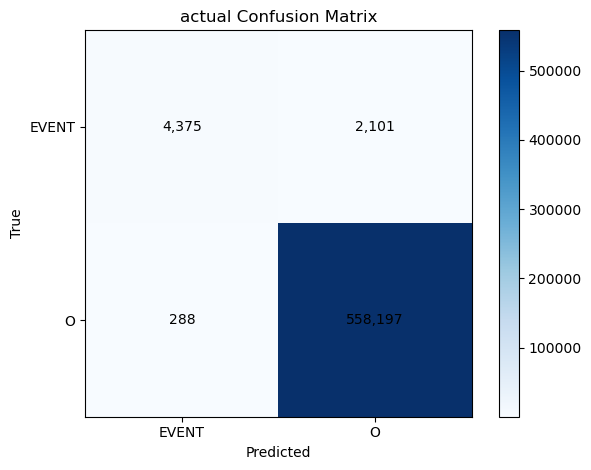



===== Experiment: synthetic =====


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/7902 [00:00<?, ? examples/s]

Map:   0%|          | 0/879 [00:00<?, ? examples/s]

Map:   0%|          | 0/35160 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.007247,0.999384,0.998247,0.998815,0.997734
2,No log,0.005676,0.999051,0.999037,0.999044,0.998171
3,No log,0.005380,0.999193,0.998979,0.999086,0.998251



Evaluating on dev for synthetic



Classification Report for synthetic:
              precision    recall  f1-score   support

           O     0.9979    0.9949    0.9964    558485
       EVENT     0.6487    0.8196    0.7242      6476

    accuracy                         0.9928    564961
   macro avg     0.8233    0.9072    0.8603    564961
weighted avg     0.9939    0.9928    0.9933    564961



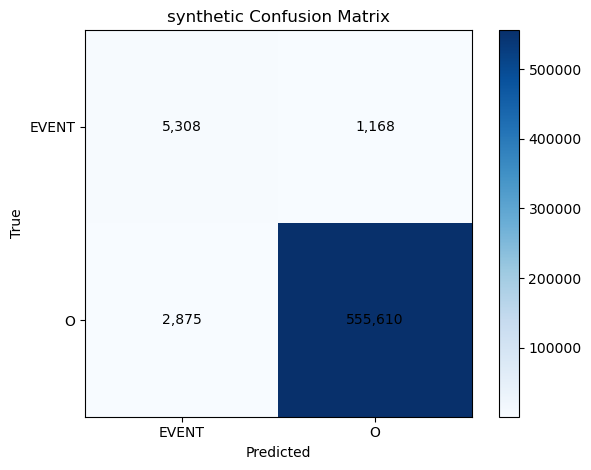



===== Experiment: both =====


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/69388 [00:00<?, ? examples/s]

Map:   0%|          | 0/7710 [00:00<?, ? examples/s]

Map:   0%|          | 0/35160 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.005600,0.004840,0.999470,0.999030,0.999250,0.998556
2,0.003800,0.004041,0.999300,0.999395,0.999348,0.998744
3,0.002800,0.004127,0.999333,0.999383,0.999358,0.998764



Evaluating on dev for both



Classification Report for both:
              precision    recall  f1-score   support

           O     0.9988    0.9995    0.9992    558485
       EVENT     0.9550    0.8976    0.9254      6476

    accuracy                         0.9983    564961
   macro avg     0.9769    0.9486    0.9623    564961
weighted avg     0.9983    0.9983    0.9983    564961



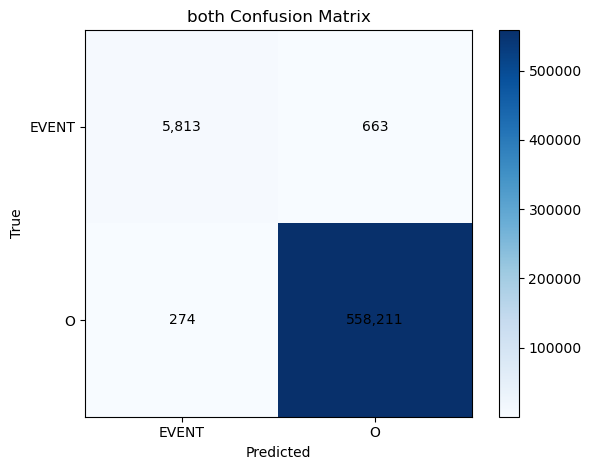

In [1]:
import os
import re
from glob import glob
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)
from sklearn.metrics import (
     classification_report,
     precision_recall_fscore_support,
     accuracy_score,
     confusion_matrix,
)
import torch
torch.cuda.empty_cache()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODEL_DIR = "../../../nlp_models/bert_models/clinicalBERT_local/"
SAVE_DIR = "../finedtuned_bert_events_experiment2/"
BATCH_SIZE = 64

# 1. Read a CoNLL file into [{"tokens":…, "labels":…}, …]
def read_conll_file(path):
    examples, tokens, labels = [], [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if tokens:
                    examples.append({"tokens": tokens, "labels": labels})
                    tokens, labels = [], []
                    
            if "\t" in line:
                parts = line.split("\t")
            else:
                parts = re.split(r"\s+", line, maxsplit=1)
            if len(parts) < 2:
                continue

            token, label = parts[0], parts[-1]
            tokens.append(token)
            labels.append(label)
            
        if tokens:
            examples.append({"tokens": tokens, "labels": labels})
            
    return examples

# 2. Get file paths for each experiment
def get_paths(experiment):
    actual_train = glob("../conll_data/events/*/train/**/*.conll", recursive=True)
    dev_paths = glob("../conll_data/events/*/dev/**/*.conll", recursive=True)
    synthetic_train = glob("../conll_data/synthetic2/events/*/*.conll")
#     synthetic_train += glob("../conll_data/synthetic2/*/*.conll")
    
    if experiment == "actual":
        train_paths = actual_train
    elif experiment == "synthetic":
        train_paths = synthetic_train
    elif experiment == "both":
        train_paths = actual_train + synthetic_train
    else:
        raise ValueError(f"Unknown experiment {experiment}")
        
    return train_paths, dev_paths

# 3. Main loop over experiments
experiments = ["actual", "synthetic", "both"]
for exp in experiments:
    print(f"\n\n===== Experiment: {exp} =====")
    train_files, dev_files = get_paths(exp)

    # 3a. Read examples
    train_exs = [ex for p in train_files for ex in read_conll_file(p)]
    dev_exs = [ex for p in dev_files for ex in read_conll_file(p)]

    # 3b. Split train → train / valid (90/10)
    train_exs, valid_exs = train_test_split(train_exs, test_size=0.1, random_state=42)

    # 3c. Build label list (["EVENT","O"])
    all_labels = sorted({lab for ex in train_exs + valid_exs + dev_exs for lab in ex["labels"]})
    label2id   = {l:i for i,l in enumerate(all_labels)}
    id2label   = {i:l for l,i in label2id.items()}

    for ex in (train_exs + valid_exs + dev_exs):
        ex["label_ids"] = [label2id[l] for l in ex["labels"]]

    # 3e. Create Hugging Face datasets
    ds_train = Dataset.from_list([{"tokens":ex["tokens"], "labels":ex["label_ids"]} for ex in train_exs])
    ds_valid = Dataset.from_list([{"tokens":ex["tokens"], "labels":ex["label_ids"]} for ex in valid_exs])
    ds_test  = Dataset.from_list([{"tokens":ex["tokens"], "labels":ex["label_ids"]} for ex in dev_exs])
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
    tokenizer.model_max_length = 512
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_DIR,
        num_labels=len(all_labels),
        id2label=id2label,
        label2id=label2id,
    )
    data_collator = DataCollatorForTokenClassification(tokenizer)

    # 4. Tokenize & align labels
    def tokenize_and_align(ex):
        toks = tokenizer(ex["tokens"], is_split_into_words=True, truncation=True)
        word_ids = toks.word_ids()
        prev_word_idx = None
        lab_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                lab_ids.append(-100)
            elif word_idx != prev_word_idx:
                lab_ids.append(ex["labels"][word_idx])
            else:
                lab_ids.append(ex["labels"][word_idx])
            prev_word_idx = word_idx
        toks["labels"] = lab_ids
        return toks

    ds_train = ds_train.map(tokenize_and_align, batched=False)
    ds_valid = ds_valid.map(tokenize_and_align, batched=False)
    ds_test  = ds_test.map(tokenize_and_align, batched=False)

    # 5. Metrics callback using seqeval
    def compute_metrics(p):
        logits, label_ids = p
        preds = np.argmax(logits, axis=2).flatten()
        labels = label_ids.flatten()

        # mask out subword positions
        mask = labels != -100
        true_labels = labels[mask]
        true_preds  = preds[mask]

        precision, recall, f1, _ = precision_recall_fscore_support(
            true_labels, true_preds,
            labels=[label2id["EVENT"] ],
            average="binary",
            zero_division=0,
        )
        acc = accuracy_score(true_labels, true_preds)

        return {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": acc
        }
    
    # 6. Training arguments
    args = TrainingArguments(
        output_dir=f"{SAVE_DIR}/{exp}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        report_to=[],
    )

    # 7. Train
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds_train,
        eval_dataset=ds_valid,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
    )
    trainer.train()
    tokenizer.save_pretrained(f"{SAVE_DIR}/{exp}")
    trainer.save_model(f"{SAVE_DIR}/{exp}")

    print(f"\nEvaluating on dev for {exp}")
    preds_output = trainer.predict(ds_test)
    logits, label_ids = preds_output.predictions, preds_output.label_ids
    preds = np.argmax(logits, axis=2)

    mask = label_ids != -100
    flat_true_ids = label_ids[mask]
    flat_pred_ids = preds[mask]

    event_id = label2id["EVENT"]
    flat_true = [int(id_ == event_id) for id_ in flat_true_ids]
    flat_pred = [int(id_ == event_id) for id_ in flat_pred_ids]
    
    names = ["O", "EVENT"]
    report = classification_report(
        flat_true,
        flat_pred,
        labels=[0,1],
        target_names=names,
        digits=4
    )
    print(f"\nClassification Report for {exp}:\n{report}")
    num_labels = len(all_labels)
    cm = confusion_matrix(
        flat_true_ids,
        flat_pred_ids,
        labels=list(range(num_labels))
    )

    fig, ax = plt.subplots()
    cax = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(cax)

    n_rows, n_cols = cm.shape
    for i in range(n_rows):
        for j in range(n_cols):
            ax.text(
                j, i,           
                f"{cm[i, j]:,}",
                ha="center",
                va="center",
                color="black"
            )

    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    ax.set_xticklabels(["EVENT", "O"])
    ax.set_yticklabels(["EVENT", "O"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{exp} Confusion Matrix")
    plt.tight_layout()
    plt.show()



===== Evaluation: actual =====
              precision    recall  f1-score   support

       EVENT     0.9558    0.8303    0.8886     12136
           O     0.9980    0.9995    0.9988   1033752

    accuracy                         0.9976   1045888
   macro avg     0.9769    0.9149    0.9437   1045888
weighted avg     0.9975    0.9976    0.9975   1045888



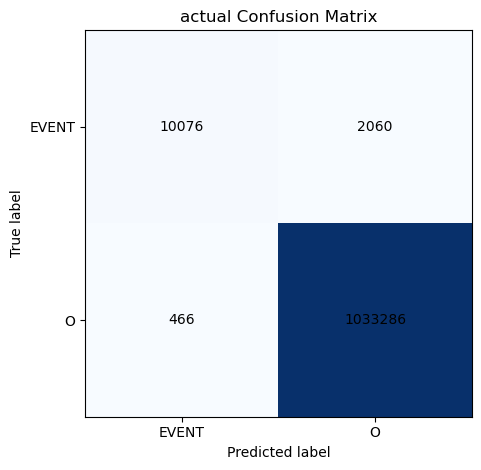



===== Evaluation: synthetic =====
              precision    recall  f1-score   support

       EVENT     0.6421    0.8180    0.7194     12136
           O     0.9979    0.9946    0.9962   1033752

    accuracy                         0.9926   1045888
   macro avg     0.8200    0.9063    0.8578   1045888
weighted avg     0.9937    0.9926    0.9930   1045888



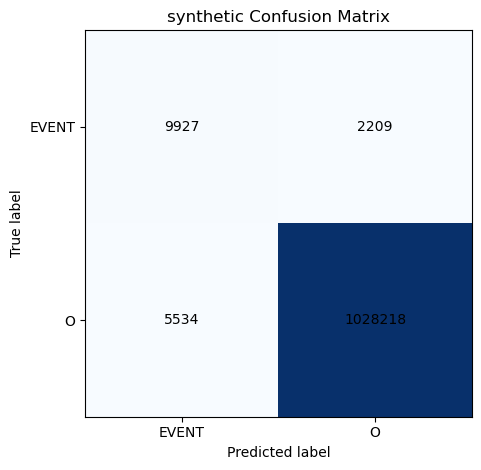



===== Evaluation: both =====
              precision    recall  f1-score   support

       EVENT     0.9524    0.8781    0.9137     12136
           O     0.9986    0.9995    0.9990   1033752

    accuracy                         0.9981   1045888
   macro avg     0.9755    0.9388    0.9564   1045888
weighted avg     0.9980    0.9981    0.9980   1045888



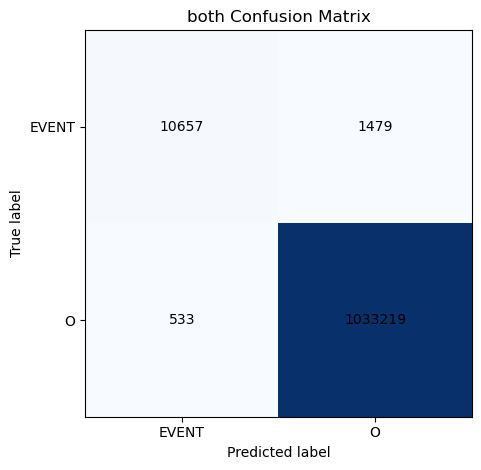

In [1]:
# DEV testing with medSpacy sentence tokenizer

import os
import re
import gc
from glob import glob
import itertools

import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

import spacy
from medspacy.sentence_splitting import PyRuSHSentencizer

# ——————————————————————————————————————————————————————————————————————————
# 1. Read CoNLL file into list of {"tokens":…, "labels":…}
# ——————————————————————————————————————————————————————————————————————————
def read_conll_file(path):
    examples, tokens, labels = [], [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if tokens:
                    examples.append({"tokens": tokens, "labels": labels})
                    tokens, labels = [], []
                continue
            parts = line.split("\t") if "\t" in line else re.split(r"\s+", line, maxsplit=1)
            if len(parts) < 2:
                continue
            token, label = parts[0], parts[-1]
            tokens.append(token)
            labels.append(label)
        if tokens:
            examples.append({"tokens": tokens, "labels": labels})
    return examples

# ——————————————————————————————————————————————————————————————————————————
# 2. Load dev set (CoNLL files under ../conll_data/events/*/dev/)
# ——————————————————————————————————————————————————————————————————————————
dev_paths = glob("../conll_data/test/event/**/*.conll", recursive=True)
dev_exs = [ex for p in dev_paths for ex in read_conll_file(p)]

# ——————————————————————————————————————————————————————————————————————————
# 3. Setup MedSpaCy sentencizer
# ——————————————————————————————————————————————————————————————————————————
nlp_sent = spacy.blank("en")
nlp_sent.add_pipe("medspacy_pyrush", config={})

# ——————————————————————————————————————————————————————————————————————————
# 4. Helper: split one example into sentence‐level (tokens, labels) chunks
# ——————————————————————————————————————————————————————————————————————————
def split_into_sentences(tokens, labels):
    text = " ".join(tokens)
    doc = nlp_sent(text)
    segments = []
    token_idx = 0
    for sent in doc.sents:
        sent_words = [tok.text for tok in sent]
        length = len(sent_words)
        sent_tokens = tokens[token_idx: token_idx + length]
        sent_labels = labels[token_idx: token_idx + length]
        if len(sent_tokens) != length:
            sent_tokens = tokens[token_idx:]
            sent_labels = labels[token_idx:]
        segments.append((sent_tokens, sent_labels))
        token_idx += length
    if token_idx < len(tokens):
        segments.append((tokens[token_idx:], labels[token_idx:]))
    return segments

# ——————————————————————————————————————————————————————————————————————————
# 5. Main evaluation loop (with confusion matrix)
# ——————————————————————————————————————————————————————————————————————————
SAVE_DIR = "../finedtuned_bert_events_experiment2"
experiments = ["actual", "synthetic", "both"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for exp in experiments:
    print(f"\n\n===== Evaluation: {exp} =====")
    model_dir = os.path.join(SAVE_DIR, exp)

    # load tokenizer & model
    tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=True)
    model = AutoModelForTokenClassification.from_pretrained(model_dir, device_map='auto')
    model.eval()

    # grab the label mappings
    label2id = model.config.label2id
    id2label = model.config.id2label
    all_label_ids = sorted(id2label.keys())
    all_label_names = [id2label[i] for i in all_label_ids]

    y_true_ids = []
    y_pred_ids = []

    for ex in dev_exs:
        for sent_tokens, sent_labels in split_into_sentences(ex["tokens"], ex["labels"]):
            enc = tokenizer(
                sent_tokens,
                is_split_into_words=True,
                return_tensors="pt",
                truncation=True,
                max_length=tokenizer.model_max_length,
            )
            word_ids = enc.word_ids(batch_index=0)

            aligned_labels = []
            prev_w = None
            for w in word_ids:
                if w is None:
                    aligned_labels.append(-100)
                elif w != prev_w:
                    aligned_labels.append(label2id[sent_labels[w]])
                else:
                    aligned_labels.append(label2id[sent_labels[w]])
                prev_w = w

            enc = {k: v.to(device) for k, v in enc.items()}
            with torch.no_grad():
                outputs = model(**enc)
            logits = outputs.logits.squeeze().cpu().numpy()
            preds = np.argmax(logits, axis=-1)

            mask = np.array(aligned_labels) != -100
            y_true_ids.extend(np.array(aligned_labels)[mask].tolist())
            y_pred_ids.extend(preds[mask].tolist())

    # map to string labels
    y_true = [id2label[i] for i in y_true_ids]
    y_pred = [id2label[i] for i in y_pred_ids]

    # classification report (EVENT only)
    print(classification_report(
        y_true,
        y_pred,
        labels=["EVENT", "O"],
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred, labels=all_label_names)
    
    # ——— Plot heatmap ———
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f"{exp} Confusion Matrix")
    tick_marks = np.arange(len(all_label_names))
    plt.xticks(tick_marks, all_label_names)
    plt.yticks(tick_marks, all_label_names)

    # overlay counts
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="black"
                )

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    
    del model
    del tokenizer
    gc.collect()

In [11]:
# Inference

from medspacy.sentence_splitting import PyRuSHSentencizer
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

MODEL_DIR = "../finedtuned_bert_events_experiment2/both"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR, device_map="auto")
nlp_ner = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")
nlp_sent = spacy.blank("en")
nlp_sent.add_pipe("medspacy_pyrush")

def ner_events(text):
    ents = []
    doc = nlp_sent(text)
    for sent in doc.sents:
        sent_text = sent.text
        offset = sent.start_char
        for e in nlp_ner(sent_text):
            ents.append({
                "entity": e["word"],
                "start": offset + e["start"],
                "end": offset + e["end"],
                "type": e.get("entity_group")
            })
    return ents

df = pd.read_csv('../entity_tags_test.csv')
# df = df[(df['split_type']=='dev') & (df['entity_type']=='EVENT')]
df = df[df['entity_type']=='EVENT']
# pth = df['note_path'].unique()
idx = 6
with open(pth[idx], "r", encoding="utf-8") as f:
    text = f.read()
results = ner_events(text)

print("Actual entities:")
print(df[df['note_path']==pth[idx]]['entity'])

print("\n\nPredictions: ")
for i in results:
    print(i["entity"])

Device set to use cuda:0


Actual entities:
31       Taxotere
32    carboplatin
33      Herceptin
35      Herceptin
37      Herceptin
39       Arimidex
41          chemo
Name: entity, dtype: object


Predictions: 
taxotere
carboplatin
herceptin
herceptin
herceptin
arimidex
chemo
herceptin
arimidex


In [17]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import spacy
import pandas as pd

MODEL_DIR = "../finedtuned_bert_events_experiment2/both"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR, device_map="auto")
nlp_ner = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")
nlp_sent = spacy.blank("en")
nlp_sent.add_pipe("medspacy_pyrush")

def ner_events(text):
    ents = []
    doc = nlp_sent(text)
    for sent in doc.sents:
        sent_text = sent.text
        offset = sent.start_char
        for e in nlp_ner(sent_text):
            ents.append({
                "entity": e["word"],
                "start": offset + e["start"],
                "end": offset + e["end"],
                "type": e.get("entity_group")
            })
    return ents

df = pd.read_csv('../entity_tags_test.csv')
df = df[df['entity_type']=='EVENT']
pth = df['note_path'].unique()

fps = []
fns = []
for note_path in pth:
    with open(note_path, "r", encoding="utf-8") as f:
        text = f.read()
    preds = ner_events(text)

    # build gold list for this note
    gold_rows = df[df['note_path']==note_path]
    gold_list = [
        {'start': int(r.span_start), 'end': int(r.span_end), 'entity': r.entity}
        for r in gold_rows.itertuples()
    ]

    # build pred list in same format
    pred_list = [
        {'start': int(e['start']), 'end': int(e['end']), 'entity': e['entity']}
        for e in preds
    ]

    fp = [e for e in pred_list if e not in gold_list]
    fn = [g for g in gold_list if g not in pred_list]

    fps.append({'note_path': note_path, 'false_positive': fp})
    fns.append({'note_path': note_path, 'false_negative': fn})

pd.DataFrame(fps).to_csv('../test_false_positives.csv', index=False)
pd.DataFrame(fns).to_csv('../test_false_negatives.csv', index=False)

Device set to use cuda:0


In [8]:
# root = Path('')
# file_paths = []

# for p in root.rglob('*'):
#     if p.is_file():
#         file_paths.append(p)

# print(f"Total files found: {len(file_paths)}")
# for p in file_paths:
#     print(p)

2121


In [1]:
# Inference EVENT

import subprocess
import os
import re
import pandas as pd
import glob
from tqdm import tqdm
import spacy
from medspacy.sentence_splitting import PyRuSHSentencizer
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline


MODEL_DIR = "../finedtuned_bert_events_experiment2/both"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR, device_map="auto")
nlp_ner = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple", framework="pt")
nlp_sent = spacy.blank("en")
nlp_sent.add_pipe("medspacy_pyrush")


def ner_events(text):
    """
    Perform event-level named entity recognition on the input text.

    Splits the input into sentences using MedSpaCy’s PyRuSH sentence splitter,
    then applies a HuggingFace NER pipeline to each sentence. Returns a list of
    event entities with their character offsets in the original text.

    Args:
        text (str): The raw document text to analyze for event entities.

    Returns:
        List[dict]: A list of dictionaries, each containing:
            - "entity" (str): The text of the detected entity.
            - "start" (int): The start character index in the original text.
            - "end" (int): The end character index in the original text.
            - "type" (str): The entity label/group assigned by the NER model.
    """
    ents = []
    doc = nlp_sent(text)
    for sent in doc.sents:
        sent_text = sent.text
        offset = sent.start_char
        for e in nlp_ner(sent_text):
            ents.append({
                "entity": e["word"],
                "start": offset + e["start"],
                "end": offset + e["end"],
                "type": e.get("entity_group")
            })
    return ents

# df = pd.read_csv('../entity_tags_test.csv')
entity_list = []
# dev_pths = df[df['split_type']=='test']['note_path'].unique()
# dev_pths = glob.glob("/home/jainv/dr_osb_lab/ChemoTask/chemoTimelines2025_test_data/subtask2/Patient_Notes/**/*.txt", recursive=True)
dev_pths = glob.glob("/home/jainv/dr_osb_lab/ChemoTask/chemoTimelines2024_train_dev_labeled/subtask2/Patient_Notes/**/*.txt", recursive=True)
print("Total notes: ", len(dev_pths))

for pth in tqdm(dev_pths):
    text = open(pth, 'r').read()
    events_list = ner_events(text)
    if len(events_list) == 0:
        print("No events detected.")
    entity_list.append(
        {
            "note_path" : pth
            "events_list" : events_list,
        }
    )

pd.DataFrame.from_dict(entity_list).to_csv("../dev_entities_events_subtask2.csv", index=False)
print("NER complete")

Device set to use cuda:0


Total notes:  4182


  0%|          | 1/4182 [00:01<1:41:36,  1.46s/it]

No events detected.


  0%|          | 3/4182 [00:01<33:15,  2.09it/s]  

...

100%|█████████▉| 4181/4182 [27:44<00:00,  6.19it/s]

No events detected.
No events detected.


100%|██████████| 4182/4182 [27:46<00:00,  2.51it/s]

No events detected.


NER complete


In [12]:
import pandas as pd

df = pd.read_csv("../dev_entities_events_subtask2.csv")
df[df['events_list'].str.len()>2]

"[{'entity': 'chemoradiation', 'start': 7588, 'end': 7602, 'type': 'EVENT'}]"

In [15]:
import pandas as pd
from glob import glob

df1 = pd.read_csv('../test_entities_events_subtask2.csv')
df_list = [pd.read_csv(fn) for fn in glob('../test_entities_timex_subtask2_*.csv')]
df2 = pd.concat(df_list, ignore_index=True)

df3 = pd.merge(df1[['note_path','events_list']], df2, on='note_path', how='left')
df3['note_path'] = df3['note_path'].apply(lambda x: '/'.join(x.split('/')[5:]))
df3.to_csv('../test_entities_subtask2.csv', index=False)

In [11]:
import pandas as pd

df1 = pd.read_csv('../dev_entities_events_subtask2.csv')
df1["patient_num"] = df1["note_path"].apply(lambda x: x.split('/')[10])
df1["cancer_type"] = df1["note_path"].apply(lambda x: x.split('/')[8])

In [42]:
df3[df3['events_list'].str.len()>2].shape
# df3[(df3['timex_list'].str.len()<=2) & (df3['events_list'].str.len()>2)].shape

(812, 5)

### Modifiers

In [ ]:
# 2 models with single head for to predict both pol vals and same for mod vals

import os 
import json
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ====== CONFIG ======
MODEL_NAME = "../../../nlp_models/bert_models/clinicalBERT_local/"
MAX_LENGTH = 512
BATCH_SIZE = 64
EPOCHS = 16
LR = 3e-5
SAVE_DIR = "../finedtuned_bert_modifiers_exp/"
os.makedirs(SAVE_DIR, exist_ok=True)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

polarity_vocab = {'pos': 0, 'neg': 1}
modality_vocab = {'actual': 0, 'generic': 1, 'hypothetical': 2, 'hedged': 3}

def parse_synthetic_generated_notes(synth_df):
    rows = []
    # capture tag attrs + inner text
    event_tag_re = re.compile(
        r'<EVENT\s+polarity=(\w+)\s+modality=(\w+)>\s*(.*?)\s*</EVENT>',
        re.DOTALL | re.IGNORECASE
    )

    for idx, row in synth_df.iterrows():
        raw = row['generated_note']
        fake_file = f"synthetic_{idx}.txt"

        # 1) find all event matches & their raw spans
        matches = []
        skip_regions = []
        for m in event_tag_re.finditer(raw):
            pol = m.group(1).lower()
            mod = m.group(2).lower()
            txt = m.group(3)
            raw_start, raw_end = m.span(3)   # span of the inner text
            matches.append((raw_start, raw_end, pol, mod, txt))

            # opening tag span: from start of `<EVENT…>` up to inner text
            open_start, open_end = m.span(0)[0], raw_start
            skip_regions.append((open_start, open_end))

            # closing tag span: from end of inner text to `</EVENT>`
            close_start, close_end = raw_end, m.span(0)[1]
            skip_regions.append((close_start, close_end))

        # 2) build a mask marking which raw‐indices to KEEP
        N = len(raw)
        keep = [True] * N
        for a, b in skip_regions:
            # clamp to valid range just in case
            a = max(0, a)
            b = min(N, b)
            for i in range(a, b):
                keep[i] = False

        # 3) build raw_to_clean & clean_text in one pass
        raw_to_clean = {}
        clean_chars = []
        cidx = 0
        for ridx, ch in enumerate(raw):
            if keep[ridx]:
                raw_to_clean[ridx] = cidx
                clean_chars.append(ch)
                cidx += 1
        clean_text = "".join(clean_chars)

        # 4) emit rows using the mapped spans
        for raw_s, raw_e, pol, mod, txt in matches:
            # map start & end (end is exclusive in Python)
            cs = raw_to_clean[raw_s]
            ce = raw_to_clean[raw_e - 1] + 1
            rows.append({
                'note_path': fake_file,
                'span_start': cs,
                'span_end':   ce,
                'entity_type': 'EVENT',
                'polarity': pol,
                'contextualModality': mod,
                'split_type': row.get('split_type'),
                'text': clean_text
            })

    return pd.DataFrame(rows)

# ====== Dataset & Collator ======
class PolModDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.ann_df = df
        self.tokenizer = tokenizer
        self.samples = self._prepare()

    def _prepare(self):
        samples = []
        # group all event‐rows by note_path
        grouped = self.ann_df[self.ann_df['entity_type']=='EVENT'].groupby('note_path')

        for fname, group in grouped:
            text = group.iloc[0]['text']
            
            # --- tokenize with overflow + stride ---
            encoding = self.tokenizer(
                text,
                return_offsets_mapping=True,
                truncation=True,
                max_length=MAX_LENGTH,
                stride=128,
                return_overflowing_tokens=True,
            )
            all_input_ids = encoding['input_ids']
            all_attention = encoding['attention_mask']
            all_offsets = encoding['offset_mapping']

            # for each chunk, collect any events that fall inside it
            for chunk_idx, offsets in enumerate(all_offsets):
                spans, pols, mods = [], [], []
                for _, row in group.iterrows():
                    s, e = row.span_start, row.span_end
                    # find the token in this chunk covering the event start
                    tok_s = next((i for i,(os,oe) in enumerate(offsets) if os <= s < oe), None)
                    # same for event end - 1
                    tok_e = next((i for i,(os,oe) in enumerate(offsets) if os < e <= oe), None)
                    if tok_s is not None and tok_e is not None:
                        spans.append((tok_s, tok_e+1))
                        pols.append(polarity_vocab[row.polarity])
                        mods.append(modality_vocab[row.contextualModality])

                if spans:
                    samples.append({
                        'input_ids': all_input_ids[chunk_idx],
                        'attention_mask': all_attention[chunk_idx],
                        'entity_spans': spans,
                        'pol_labels': torch.tensor(pols, dtype=torch.long),
                        'mod_labels': torch.tensor(mods, dtype=torch.long),
                    })

        return samples

    def __len__(self):  
        return len(self.samples)
    
    def __getitem__(self, i):
        s = self.samples[i]
        return {
            "input_ids": torch.tensor(s["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(s["attention_mask"], dtype=torch.long),
            "entity_spans": s["entity_spans"],
            "pol_labels": s["pol_labels"],
            "mod_labels": s["mod_labels"],
        }

class Collator:
    def __init__(self, tokenizer):
        self.pad = DataCollatorWithPadding(tokenizer)

    def __call__(self, features):
        spans = [f.pop("entity_spans") for f in features]
        labs = [f.pop("labels") for f in features]
        batch = self.pad(features)              # pads input_ids & attention_mask
        batch["entity_spans"] = spans
        batch["labels"] = torch.cat(labs, dim=0)
        return batch

# ====== Focal Loss ======

class FocalLoss(nn.Module):

    def __init__(self, weight: torch.Tensor = None, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        # compute per‐example CrossEntropy
        w = self.weight
        if w is not None:
            w = w.to(logits.device)
        ce_loss = F.cross_entropy(logits, targets, weight=w, reduction="none")
        # p_t = exp(–CE)
        p_t = torch.exp(-ce_loss)
        # focal factor
        focal_factor = (1 - p_t) ** self.gamma
        loss = focal_factor * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

# ====== Trainer ======
class TaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(
            input_ids = inputs["input_ids"],
            attention_mask = inputs["attention_mask"],
            entity_spans = inputs["entity_spans"],
            labels = labels
        )
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        labels = inputs.pop("labels", None)
        spans  = inputs.pop("entity_spans", None)
        for k,v in inputs.items():
            if isinstance(v, torch.Tensor):
                inputs[k] = v.to(self.args.device)
        out = model(
            input_ids = inputs["input_ids"],
            attention_mask = inputs["attention_mask"],
            entity_spans = spans,
            labels = labels.to(self.args.device) if labels is not None else None
        )
        loss = out["loss"].detach() if labels is not None else None
        logits = out["logits"].detach().cpu()
        if prediction_loss_only:
            return (loss, None, None)
        if labels is not None:
            return (loss, logits, labels.detach().cpu())
        else:
            return (loss, logits, None)


def compute_metrics(p):
    preds = p.predictions.argmax(axis=1)
    return {"f1": f1_score(p.label_ids, preds, average="macro")}

# Load the data

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
df = pd.read_csv("../entity_tags.csv")
df = df[df.entity_type=="EVENT"].copy()
df["text"] = df.note_path.apply(lambda fn: open(fn, "r").read())
df["polarity"] = df.polarity.str.lower()
df['contextualModality'] = df.contextualModality.str.lower()

synth1 = pd.read_csv("../generated_notes_chemotask.csv")
synth2 = pd.read_csv("../generated_notes_chemotask2.csv")
synth = pd.concat([synth1, synth2])
synth = synth[synth.invalid==0].reset_index(drop=True)
if "split_type" not in synth:
    tr, dv = train_test_split(synth, test_size=0.05, random_state=42)
    tr["split_type"], dv["split_type"] = "train", "dev"
    synth = pd.concat([tr, dv], ignore_index=True)

experiments = ["actual", "synthetic", "both"]

In [ ]:
# Polarity

class PolarityDataset(PolModDataset):
    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "input_ids": torch.tensor(s["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(s["attention_mask"], dtype=torch.long),
            "entity_spans": s["entity_spans"],
            "labels": s["pol_labels"],
        }

class BertForPolarity(nn.Module):
    def __init__(self, model_name, num_labels, class_weights=None, focal_gamma: float = 2.0):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        H = self.bert.config.hidden_size
        self.classifier = nn.Linear(H, num_labels)
#         self.loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        self.loss_fn = FocalLoss(weight=class_weights, gamma=focal_gamma, reduction="mean")

    def forward(self, input_ids, attention_mask, entity_spans, labels=None):
        last = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        logits = []
        for i, spans in enumerate(entity_spans):
            for s,e in spans:
                emb = last[i, s:e].mean(0)
                logits.append(self.classifier(emb))
        logits = torch.stack(logits)
        loss = self.loss_fn(logits, labels) if labels is not None else None
        return {"loss": loss, "logits": logits}

for exp in experiments:
    if exp=="actual":
        raw = df[df.split_type=="train"]
    elif exp=="synthetic":
        raw = parse_synthetic_generated_notes(synth[synth.split_type=="train"])
    else:
        act = df[df.split_type=="train"]
        syn = parse_synthetic_generated_notes(synth[synth.split_type=="train"])
        raw = pd.concat([act, syn], ignore_index=True)

    train_df, val_df = train_test_split(
        raw, test_size=0.05, random_state=42,
        stratify=raw["polarity"]
    )

    train_ds = PolarityDataset(train_df, tokenizer)
    val_ds   = PolarityDataset(val_df, tokenizer)
    collator = Collator(tokenizer)

    weights = compute_class_weight(
        "balanced",
        classes=np.arange(len(polarity_vocab)),
        y=train_df.polarity.map(polarity_vocab)
    )
    cw = torch.tensor(weights, dtype=torch.float)

    model = BertForPolarity(MODEL_NAME, len(polarity_vocab), class_weights=cw)

    outdir = os.path.join(SAVE_DIR, exp)
    os.makedirs(outdir, exist_ok=True)
    args = TrainingArguments(
        output_dir=f"{outdir}/pol",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=LR,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to=[]
    )

    trainer = TaskTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collator,
        compute_metrics=compute_metrics
    )

    trainer.train()
    metrics = trainer.evaluate()
    print(f"\n== {exp} polarity eval ==", metrics)

    # test on held‐out dev
    dev_ds = PolarityDataset(df[df.split_type=="dev"], tokenizer)
    preds = trainer.predict(dev_ds)
    y_true = preds.label_ids
    y_pred = preds.predictions.argmax(axis=1)

    print(classification_report(y_true, y_pred,
          target_names=list(polarity_vocab.keys()), zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=polarity_vocab.keys(),
                yticklabels=polarity_vocab.keys(),
                cmap='Blues'
               )
    plt.title(f"Polarity Confusion ({exp})")
    plt.show()

    trainer.save_model(f"{outdir}/pol")
    tokenizer.save_pretrained(f"{outdir}/pol")
    json.dump(polarity_vocab, open(os.path.join(f"{outdir}/pol","polarity_vocab.json"),"w"))

In [ ]:
# Modality

class ModalityDataset(PolModDataset):
    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "input_ids": torch.tensor(s["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(s["attention_mask"], dtype=torch.long),
            "entity_spans": s["entity_spans"],
            "labels": s["mod_labels"],
        }
    
class BertForModality(nn.Module):
    def __init__(self, model_name, num_labels, class_weights=None, focal_gamma: float = 2.0):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        H = self.bert.config.hidden_size
        self.classifier = nn.Linear(H, num_labels)
#         self.loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        self.loss_fn = FocalLoss(weight=class_weights, gamma=focal_gamma, reduction="mean")

    def forward(self, input_ids, attention_mask, entity_spans, labels=None):
        last = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        logits = []
        for i, spans in enumerate(entity_spans):
            for s,e in spans:
                emb = last[i, s:e].mean(0)
                logits.append(self.classifier(emb))
        logits = torch.stack(logits)
        loss = self.loss_fn(logits, labels) if labels is not None else None
        return {"loss": loss, "logits": logits}
    
for exp in experiments:
    if exp=="actual":
        raw = df[df.split_type=="train"]
    elif exp=="synthetic":
        raw = parse_synthetic_generated_notes(synth[synth.split_type=="train"])
    else:
        act = df[df.split_type=="train"]
        syn = parse_synthetic_generated_notes(synth[synth.split_type=="train"])
        raw = pd.concat([act, syn], ignore_index=True)

    train_df, val_df = train_test_split(
        raw, test_size=0.05, random_state=42,
        stratify=raw["contextualModality"]
    )

    train_ds = ModalityDataset(train_df, tokenizer)
    val_ds = ModalityDataset(val_df, tokenizer)
    collator = Collator(tokenizer)

    weights = compute_class_weight(
        "balanced",
        classes=np.arange(len(modality_vocab)),
        y=train_df.contextualModality.map(modality_vocab)
    )
    cw = torch.tensor(weights, dtype=torch.float)

    model = BertForModality(MODEL_NAME, len(modality_vocab), class_weights=cw)

    outdir = os.path.join(SAVE_DIR, exp)
    os.makedirs(outdir, exist_ok=True)
    args = TrainingArguments(
        output_dir=f"{outdir}/mod",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=LR,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to=[]
    )

    trainer = TaskTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collator,
        compute_metrics=compute_metrics
    )

    trainer.train()
    metrics = trainer.evaluate()
    print("\n", metrics)

    # test on held‐out dev
    dev_ds = ModalityDataset(df[df.split_type=="dev"], tokenizer)
    preds = trainer.predict(dev_ds)
    y_true = preds.label_ids
    y_pred = preds.predictions.argmax(axis=1)

    print(classification_report(y_true, y_pred,
          target_names=list(modality_vocab.keys()), zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=list(modality_vocab.values()))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=modality_vocab.keys(),
                yticklabels=modality_vocab.keys(),
                cmap='Blues')
    plt.title(f"Modality Confusion ({exp})")
    plt.show()

    trainer.save_model(f"{outdir}/mod")
    tokenizer.save_pretrained(f"{outdir}/mod")
    json.dump(modality_vocab, open(os.path.join(f"{outdir}/mod","modality_vocab.json"),"w"))



=== EXP=synthetic | TASK=polarity | VALUE=POS ===
Number of examples in train set:  10281


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/9252 [00:00<?, ? examples/s]

Map:   0%|          | 0/1029 [00:00<?, ? examples/s]

Map:   0%|          | 0/35041 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.013595,0.911323,0.961179,0.935587,0.995057
2,No log,0.012015,0.918252,0.966236,0.941633,0.995527
3,No log,0.011336,0.935369,0.955867,0.945507,0.995885



-- DEV eval for synthetic/polarity/POS --



Classification Report for synthetic/polarity/POS:
              precision    recall  f1-score   support

           O     0.9968    0.9970    0.9969    557209
         POS     0.7267    0.7138    0.7202      6311

    accuracy                         0.9938    563520
   macro avg     0.8617    0.8554    0.8585    563520
weighted avg     0.9937    0.9938    0.9938    563520



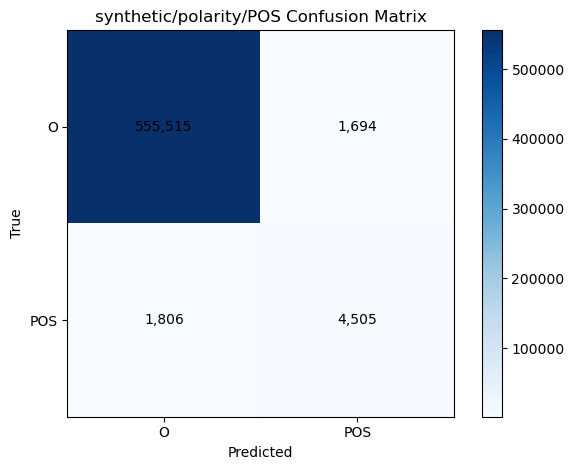



=== EXP=synthetic | TASK=polarity | VALUE=NEG ===
Number of examples in train set:  9146


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/8231 [00:00<?, ? examples/s]

Map:   0%|          | 0/915 [00:00<?, ? examples/s]

Map:   0%|          | 0/5552 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.010857,0.831711,0.717094,0.770161,0.995843
2,No log,0.009547,0.803935,0.803224,0.803579,0.996186
3,No log,0.009510,0.803037,0.817580,0.810243,0.996280



-- DEV eval for synthetic/polarity/NEG --



Classification Report for synthetic/polarity/NEG:
              precision    recall  f1-score   support

           O     0.9988    0.9999    0.9993     97700
         NEG     0.8431    0.2606    0.3981       165

    accuracy                         0.9987     97865
   macro avg     0.9209    0.6303    0.6987     97865
weighted avg     0.9985    0.9987    0.9983     97865



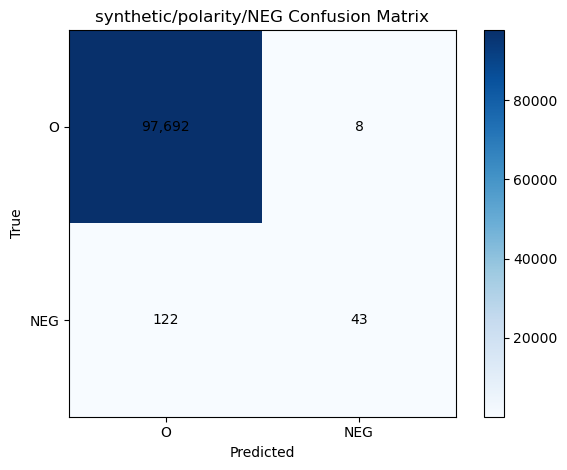



=== EXP=synthetic | TASK=modality | VALUE=HEDGED ===
Number of examples in train set:  10231


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/9207 [00:00<?, ? examples/s]

Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

Map:   0%|          | 0/1135 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.010689,0.850672,0.562437,0.677158,0.995946
2,No log,0.009953,0.890909,0.547208,0.677987,0.996071
3,No log,0.009918,0.822016,0.608376,0.699242,0.996044



-- DEV eval for synthetic/modality/HEDGED --



Classification Report for synthetic/modality/HEDGED:
              precision    recall  f1-score   support

           O     0.9907    0.9999    0.9953     23732
      HEDGED     0.0000    0.0000    0.0000       223

    accuracy                         0.9906     23955
   macro avg     0.4953    0.5000    0.4976     23955
weighted avg     0.9815    0.9906    0.9860     23955



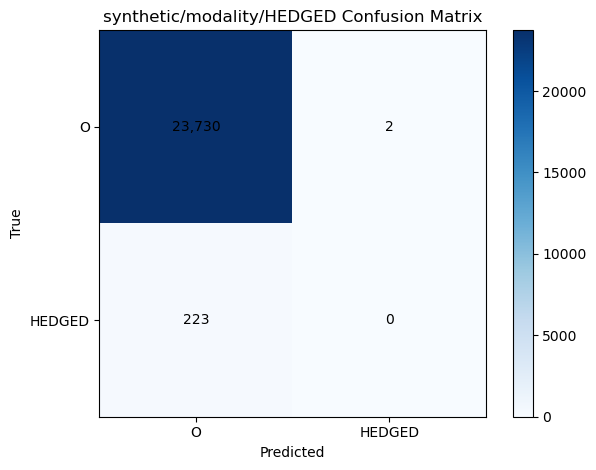



=== EXP=synthetic | TASK=modality | VALUE=HYPOTHETICAL ===
Number of examples in train set:  8695


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/7825 [00:00<?, ? examples/s]

Map:   0%|          | 0/870 [00:00<?, ? examples/s]

Map:   0%|          | 0/8393 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.008137,0.661357,0.639662,0.650328,0.996881
2,No log,0.007300,0.707521,0.631213,0.667192,0.997144
3,No log,0.007135,0.709121,0.633698,0.669291,0.997160



-- DEV eval for synthetic/modality/HYPOTHETICAL --



Classification Report for synthetic/modality/HYPOTHETICAL:
              precision    recall  f1-score   support

           O     0.9958    1.0000    0.9979    136278
HYPOTHETICAL     1.0000    0.0018    0.0035       571

    accuracy                         0.9958    136849
   macro avg     0.9979    0.5009    0.5007    136849
weighted avg     0.9959    0.9958    0.9938    136849



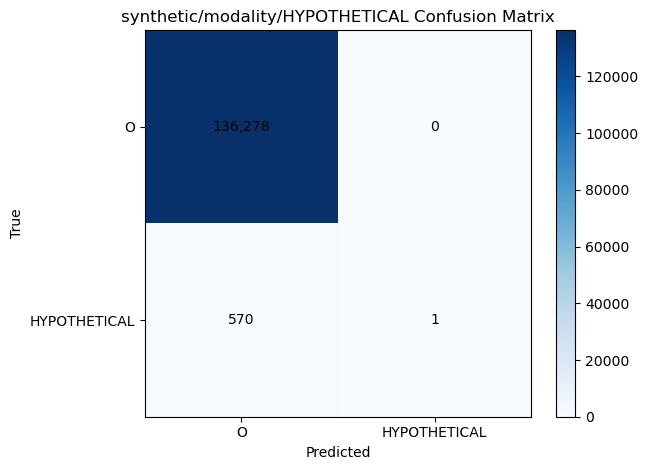



=== EXP=synthetic | TASK=modality | VALUE=GENERIC ===
Number of examples in train set:  8606


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/7745 [00:00<?, ? examples/s]

Map:   0%|          | 0/861 [00:00<?, ? examples/s]

Map:   0%|          | 0/8614 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.004614,0.844373,0.921492,0.881249,0.998540
2,No log,0.004356,0.855954,0.919161,0.886432,0.998615
3,No log,0.004266,0.860088,0.907890,0.883343,0.998590



-- DEV eval for synthetic/modality/GENERIC --



Classification Report for synthetic/modality/GENERIC:
              precision    recall  f1-score   support

           O     0.9988    0.9964    0.9976    142427
     GENERIC     0.3759    0.6469    0.4755       473

    accuracy                         0.9953    142900
   macro avg     0.6874    0.8217    0.7366    142900
weighted avg     0.9968    0.9953    0.9959    142900



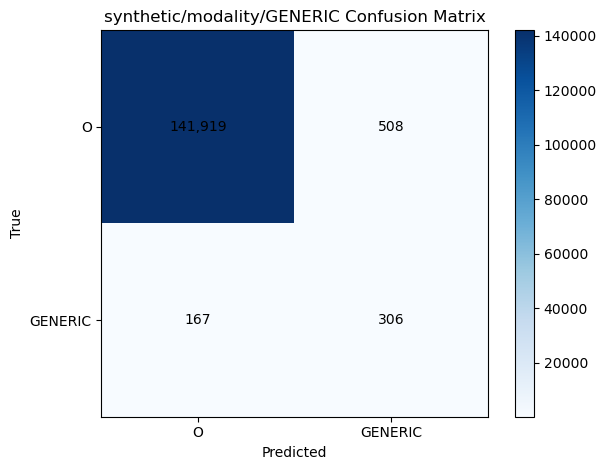



=== EXP=synthetic | TASK=modality | VALUE=ACTUAL ===
Number of examples in train set:  10281


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/9252 [00:00<?, ? examples/s]

Map:   0%|          | 0/1029 [00:00<?, ? examples/s]

Map:   0%|          | 0/32855 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.014848,0.908908,0.928625,0.918660,0.994519
2,No log,0.013729,0.905585,0.944823,0.924788,0.994878
3,No log,0.013615,0.905287,0.943735,0.924112,0.994834



-- DEV eval for synthetic/modality/ACTUAL --



Classification Report for synthetic/modality/ACTUAL:
              precision    recall  f1-score   support

           O     0.9935    0.9973    0.9954    518446
      ACTUAL     0.5704    0.3509    0.4345      5209

    accuracy                         0.9909    523655
   macro avg     0.7819    0.6741    0.7150    523655
weighted avg     0.9893    0.9909    0.9898    523655



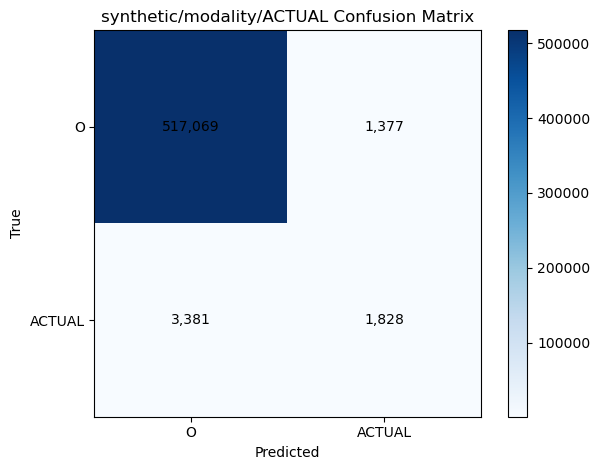



=== EXP=both | TASK=polarity | VALUE=POS ===
Number of examples in train set:  10812


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/69735 [00:00<?, ? examples/s]

Map:   0%|          | 0/7749 [00:00<?, ? examples/s]

Map:   0%|          | 0/35041 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.010100,0.009547,0.918908,0.972126,0.944768,0.996243
2,0.007600,0.009228,0.948492,0.943241,0.945859,0.996431
3,0.005700,0.009358,0.942212,0.956047,0.949079,0.996609



-- DEV eval for both/polarity/POS --



Classification Report for both/polarity/POS:
              precision    recall  f1-score   support

           O     0.9972    0.9995    0.9983    557209
         POS     0.9415    0.7546    0.8377      6311

    accuracy                         0.9967    563520
   macro avg     0.9694    0.8770    0.9180    563520
weighted avg     0.9966    0.9967    0.9965    563520



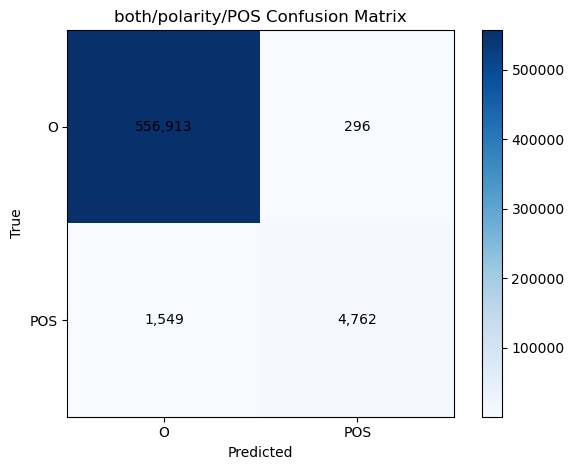



=== EXP=both | TASK=polarity | VALUE=NEG ===
Number of examples in train set:  9214


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/18586 [00:00<?, ? examples/s]

Map:   0%|          | 0/2066 [00:00<?, ? examples/s]

Map:   0%|          | 0/5552 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.009913,0.837116,0.744785,0.788256,0.996152
2,0.014300,0.009636,0.856713,0.758988,0.804895,0.996461
3,0.014300,0.009830,0.830105,0.789392,0.809237,0.996421



-- DEV eval for both/polarity/NEG --



Classification Report for both/polarity/NEG:
              precision    recall  f1-score   support

           O     0.9990    0.9998    0.9994     97700
         NEG     0.7356    0.3879    0.5079       165

    accuracy                         0.9987     97865
   macro avg     0.8673    0.6938    0.7537     97865
weighted avg     0.9985    0.9987    0.9985     97865



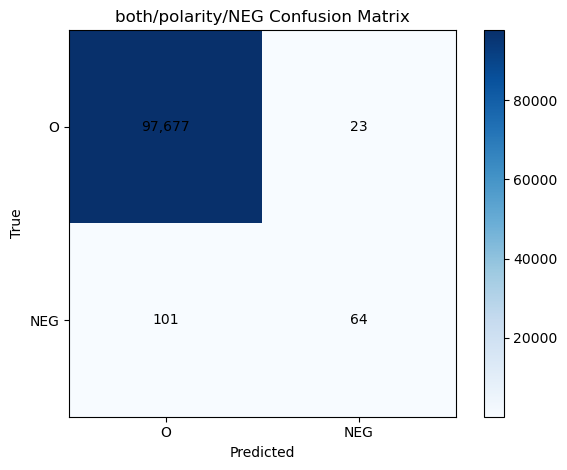



=== EXP=both | TASK=modality | VALUE=HEDGED ===
Number of examples in train set:  10275


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/14356 [00:00<?, ? examples/s]

Map:   0%|          | 0/1596 [00:00<?, ? examples/s]

Map:   0%|          | 0/1135 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.011233,0.871760,0.569732,0.689105,0.995565
2,No log,0.010939,0.913855,0.560053,0.694490,0.995749
3,0.014100,0.010796,0.829532,0.640123,0.722622,0.995761



-- DEV eval for both/modality/HEDGED --



Classification Report for both/modality/HEDGED:
              precision    recall  f1-score   support

           O     0.9916    0.9966    0.9941     23732
      HEDGED     0.2212    0.1031    0.1407       223

    accuracy                         0.9883     23955
   macro avg     0.6064    0.5499    0.5674     23955
weighted avg     0.9844    0.9883    0.9861     23955



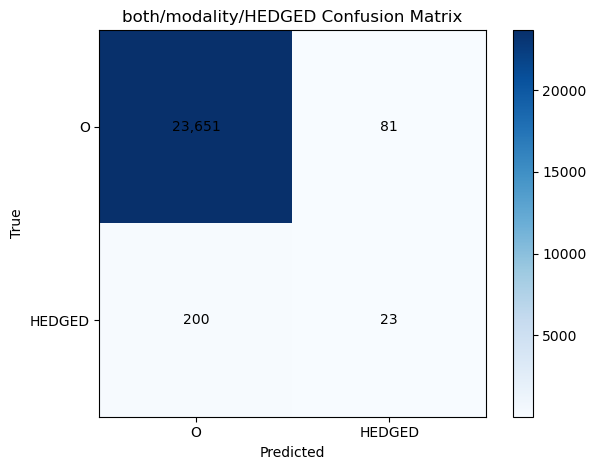



=== EXP=both | TASK=modality | VALUE=HYPOTHETICAL ===
Number of examples in train set:  8817


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/21375 [00:00<?, ? examples/s]

Map:   0%|          | 0/2375 [00:00<?, ? examples/s]

Map:   0%|          | 0/8393 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.007628,0.703291,0.603927,0.649833,0.997111
2,0.011100,0.007357,0.730040,0.608716,0.663881,0.997264
3,0.005900,0.007706,0.709945,0.615421,0.659312,0.997177



-- DEV eval for both/modality/HYPOTHETICAL --



Classification Report for both/modality/HYPOTHETICAL:
              precision    recall  f1-score   support

           O     0.9968    0.9993    0.9981    136278
HYPOTHETICAL     0.5855    0.2399    0.3404       571

    accuracy                         0.9961    136849
   macro avg     0.7911    0.6196    0.6692    136849
weighted avg     0.9951    0.9961    0.9953    136849



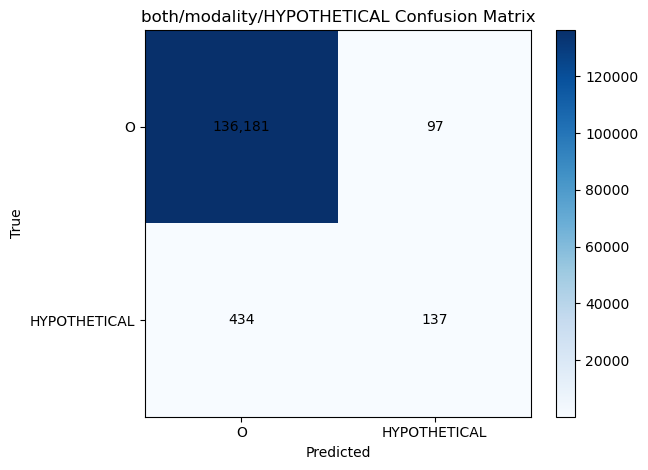



=== EXP=both | TASK=modality | VALUE=GENERIC ===
Number of examples in train set:  8670


Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at ../../../nlp_models/bert_models/clinicalBERT_local/ and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/13951 [00:00<?, ? examples/s]

Map:   0%|          | 0/1551 [00:00<?, ? examples/s]

Map:   0%|          | 0/8614 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.004433,0.908773,0.814554,0.859088,0.998468
2,No log,0.004135,0.882306,0.868153,0.875173,0.998580
3,0.007200,0.004168,0.876404,0.884977,0.880670,0.998625



-- DEV eval for both/modality/GENERIC --



Classification Report for both/modality/GENERIC:
              precision    recall  f1-score   support

           O     0.9989    0.9986    0.9987    142427
     GENERIC     0.6054    0.6617    0.6323       473

    accuracy                         0.9975    142900
   macro avg     0.8021    0.8302    0.8155    142900
weighted avg     0.9976    0.9975    0.9975    142900



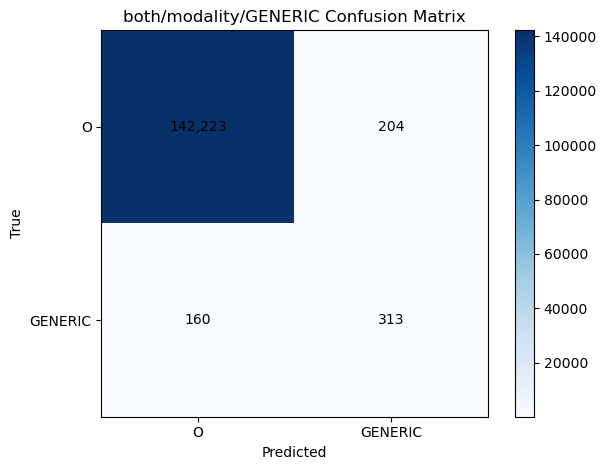



=== EXP=both | TASK=modality | VALUE=ACTUAL ===
Number of examples in train set:  10731


Map:   0%|          | 0/6959 [00:00<?, ? examples/s]

Map:   0%|          | 0/32855 [00:00<?, ? examples/s]

Detected kernel version 3.10.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.020300,0.011877,0.923529,0.923187,0.923358,0.995336
2,0.010500,0.011030,0.921656,0.931651,0.926627,0.995510
3,0.008700,0.011019,0.918860,0.943554,0.931043,0.995747



-- DEV eval for both/modality/ACTUAL --



Classification Report for both/modality/ACTUAL:
              precision    recall  f1-score   support

           O     0.9966    0.9990    0.9978    518446
      ACTUAL     0.8645    0.6625    0.7501      5209

    accuracy                         0.9956    523655
   macro avg     0.9305    0.8307    0.8740    523655
weighted avg     0.9953    0.9956    0.9953    523655



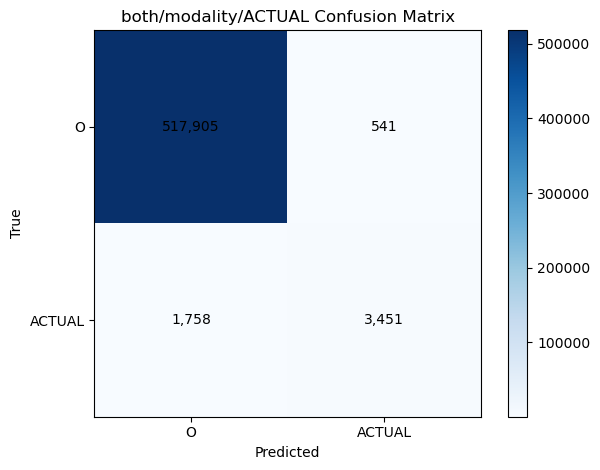

In [2]:
# Binary classification for each pol/mod

import os
from pathlib import Path
import re
from glob import glob
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)
from sklearn.metrics import (
     precision_recall_fscore_support,
     accuracy_score,
     confusion_matrix,
     classification_report
)
import torch
torch.cuda.empty_cache()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODEL_DIR = "../../../nlp_models/bert_models/clinicalBERT_local/"
BASE_DIR = "../conll_data/modifiers"
SYNTH_DIR = "../conll_data/synthetic/modifiers"
SAVE_DIR = "../finedtuned_bert_modifiers_experiment/"
BATCH_SIZE = 64
MAX_LEN = 512

def read_conll_file(path):
    examples, tokens, labels = [], [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if tokens:
                    examples.append({"tokens": tokens, "labels": labels})
                    tokens, labels = [], []
                continue
            parts = re.split(r"\s+", line, maxsplit=1)
            if len(parts) < 2:
                continue
            token, label = parts[0], parts[-1]
            tokens.append(token)
            labels.append(label.upper())
        if tokens:
            examples.append({"tokens": tokens, "labels": labels})
    return examples

def map_ids(example_list):
    for ex in example_list:
        ex["label_ids"] = [label2id[i] for i in ex["labels"]]
    return example_list

def tokenize_and_align(ex):
    toks = tokenizer(ex["tokens"], is_split_into_words=True, truncation=True)
    word_ids = toks.word_ids()
    prev = None
    lab_ids = []
    for w in word_ids:
        if w is None:
            lab_ids.append(-100)
        elif w != prev:
            lab_ids.append(ex["labels"][w])
        else:
            lab_ids.append(ex["labels"][w])
        prev = w
    toks["labels"] = lab_ids
    return toks

def compute_metrics(p):
    logits, label_ids = p
    preds = np.argmax(logits, axis=2).flatten()
    labs  = label_ids.flatten()
    mask  = labs != -100
    tp, fp, fn = 0,0,0
    for gt, pr in zip(labs[mask], preds[mask]):
        if gt==label2id[value] and pr==label2id[value]:
            tp+=1
        if gt!=label2id[value] and pr==label2id[value]:
            fp+=1
        if gt==label2id[value] and pr!=label2id[value]:
            fn+=1
    prec = tp/(tp+fp) if tp+fp>0 else 0.0
    rec  = tp/(tp+fn) if tp+fn>0 else 0.0
    f1   = 2*prec*rec/(prec+rec) if prec+rec>0 else 0.0
    acc  = accuracy_score(labs[mask], preds[mask])
    
    return {"precision":prec, "recall":rec, "f1":f1, "accuracy":acc}

experiments = ["actual", "synthetic", "both"]
tasks = ["polarity", "modality"]

for exp in experiments[1:]:
    for task in tasks:
        values = os.listdir(f"{BASE_DIR}/{task}")
        for value in values:
            print(f"\n\n=== EXP={exp} | TASK={task} | VALUE={value} ===")
            
            train_paths = []
            if exp in ("actual", "both"):
                train_paths += glob(f"{BASE_DIR}/{task}/{value}/*/train/**/*.conll", recursive=True)
            if exp in ("synthetic", "both"):
                train_paths += glob(f"../conll_data/synthetic/modifiers/{task}/*/{value}/*.conll", recursive=True)
            
            print("Number of examples in train set: ", len(train_paths))
            dev_paths = glob(f"{BASE_DIR}/{task}/{value}/*/dev/**/*.conll", recursive=True)
            

            dev_exs = [ex for p in dev_paths for ex in read_conll_file(p)]
            exs = [ex for p in train_paths for ex in read_conll_file(p)]
            train_exs, valid_exs = train_test_split(exs, test_size=0.1, random_state=42)

            all_labels = ["O", value]
            label2id   = {lab:i for i,lab in enumerate(all_labels)}
            id2label   = {i:lab for lab,i in label2id.items()}

            train_exs = map_ids(train_exs)
            valid_exs = map_ids(valid_exs)
            dev_exs2  = map_ids([ex.copy() for ex in dev_exs])

            ds_train = Dataset.from_list([{"tokens":e["tokens"], "labels":e["label_ids"]} for e in train_exs])
            ds_valid = Dataset.from_list([{"tokens":e["tokens"], "labels":e["label_ids"]} for e in valid_exs])
            ds_dev   = Dataset.from_list([{"tokens":e["tokens"], "labels":e["label_ids"]} for e in dev_exs2])

            tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
            tokenizer.model_max_length = MAX_LEN
            model = AutoModelForTokenClassification.from_pretrained(
                MODEL_DIR,
                num_labels=len(all_labels),
                id2label=id2label,
                label2id=label2id,
            )
            data_collator = DataCollatorForTokenClassification(tokenizer)

            ds_train = ds_train.map(tokenize_and_align, batched=False)
            ds_valid = ds_valid.map(tokenize_and_align, batched=False)
            ds_dev = ds_dev.map(tokenize_and_align, batched=False)

            out_dir = os.path.join(SAVE_DIR, exp, task, value)
            args = TrainingArguments(
                output_dir=out_dir,
                eval_strategy="epoch",
                save_strategy="epoch",
                learning_rate=3e-5,
                per_device_train_batch_size=BATCH_SIZE,
                per_device_eval_batch_size=BATCH_SIZE,
                num_train_epochs=3,
                weight_decay=0.01,
                load_best_model_at_end=True,
                metric_for_best_model="f1",
                report_to=[],
            )

            # Trainer
            trainer = Trainer(
                model=model,
                args=args,
                train_dataset=ds_train,
                eval_dataset=ds_valid,
                compute_metrics=compute_metrics,
                data_collator=data_collator,
            )
            trainer.train()
            trainer.save_model(out_dir)
            tokenizer.save_pretrained(out_dir)

            # final eval on dev
            print(f"\n-- DEV eval for {exp}/{task}/{value} --")
            preds_output = trainer.predict(ds_dev)
            logits, label_ids = preds_output.predictions, preds_output.label_ids
            preds = np.argmax(logits, axis=2)

            mask = label_ids != -100
            flat_true_ids = label_ids[mask]
            flat_pred_ids = preds[mask]

            positive_id = label2id[value]
            flat_true = [int(i == positive_id) for i in flat_true_ids]
            flat_pred = [int(i == positive_id) for i in flat_pred_ids]

            # classification report
            names = ["O", value]
            report = classification_report(
                flat_true,
                flat_pred,
                labels=[0, 1],
                target_names=names,
                digits=4,
                zero_division=0,
            )
            print(f"\nClassification Report for {exp}/{task}/{value}:\n{report}")

            cm = confusion_matrix(
                flat_true,
                flat_pred,
                labels=[0, 1]
            )
            fig, ax = plt.subplots()
            cax = ax.imshow(cm, interpolation='nearest', cmap='Blues')
            fig.colorbar(cax)

            for i in range(2):
                for j in range(2):
                    ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(names)
            ax.set_yticklabels(names)
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
            ax.set_title(f"{exp}/{task}/{value} Confusion Matrix")

            plt.tight_layout()
            plt.show()

### Modifier debugging

In [ ]:
import os
import json
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ====== CONFIG ======
# MODEL_NAME = "../../../nlp_models/bert_models/clinicalBERT_local/"
# MAX_LENGTH = 512
# BATCH_SIZE = 64
# EPOCHS = 16
# LR = 3e-5
# SAVE_DIR = "../finedtuned_bert_modifiers_exp/"
# os.makedirs(SAVE_DIR, exist_ok=True)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

polarity_vocab = {'pos': 0, 'neg': 1}
modality_vocab = {'actual': 0, 'generic': 1, 'hypothetical': 2, 'hedged': 3}

def parse_synthetic_generated_notes(synth_df):
    rows = []
    # capture tag attrs + inner text
    event_tag_re = re.compile(
        r'<EVENT\s+polarity=(\w+)\s+modality=(\w+)>\s*(.*?)\s*</EVENT>',
        re.DOTALL | re.IGNORECASE
    )

    for idx, row in synth_df.iterrows():
        raw = row['generated_note']
        fake_file = f"synthetic_{idx}.txt"

        # 1) find all event matches & their raw spans
        matches = []
        skip_regions = []
        for m in event_tag_re.finditer(raw):
            pol = m.group(1).lower()
            mod = m.group(2).lower()
            txt = m.group(3)
            raw_start, raw_end = m.span(3)   # span of the inner text
            matches.append((raw_start, raw_end, pol, mod, txt))

            # opening tag span: from start of `<EVENT…>` up to inner text
            open_start, open_end = m.span(0)[0], raw_start
            skip_regions.append((open_start, open_end))

            # closing tag span: from end of inner text to `</EVENT>`
            close_start, close_end = raw_end, m.span(0)[1]
            skip_regions.append((close_start, close_end))

        # 2) build a mask marking which raw‐indices to KEEP
        N = len(raw)
        keep = [True] * N
        for a, b in skip_regions:
            # clamp to valid range just in case
            a = max(0, a)
            b = min(N, b)
            for i in range(a, b):
                keep[i] = False

        # 3) build raw_to_clean & clean_text in one pass
        raw_to_clean = {}
        clean_chars = []
        cidx = 0
        for ridx, ch in enumerate(raw):
            if keep[ridx]:
                raw_to_clean[ridx] = cidx
                clean_chars.append(ch)
                cidx += 1
        clean_text = "".join(clean_chars)

        # 4) emit rows using the mapped spans
        for raw_s, raw_e, pol, mod, txt in matches:
            # map start & end (end is exclusive in Python)
            cs = raw_to_clean[raw_s]
            ce = raw_to_clean[raw_e - 1] + 1
            rows.append({
                'note_path': fake_file,
                'span_start': cs,
                'span_end':   ce,
                'entity_type': 'EVENT',
                'polarity': pol,
                'contextualModality': mod,
                'split_type': row.get('split_type'),
                'text': clean_text
            })

    return pd.DataFrame(rows)

# ====== Dataset & Collator ======
class PolModDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.ann_df = df
        self.tokenizer = tokenizer
        self.samples = self._prepare()

    def _prepare(self):
        samples = []
        # group all event‐rows by note_path
        grouped = self.ann_df[self.ann_df['entity_type']=='EVENT'].groupby('note_path')

        for fname, group in grouped:
            text = group.iloc[0]['text']
            
            # --- tokenize with overflow + stride ---
            encoding = self.tokenizer(
                text,
                return_offsets_mapping=True,
                truncation=True,
                max_length=MAX_LENGTH,
                stride=128,
                return_overflowing_tokens=True,
            )
            all_input_ids    = encoding['input_ids']
            all_attention   = encoding['attention_mask']
            all_offsets     = encoding['offset_mapping']

            # for each chunk, collect any events that fall inside it
            for chunk_idx, offsets in enumerate(all_offsets):
                spans, pols, mods = [], [], []
                for _, row in group.iterrows():
                    s, e = row.span_start, row.span_end
                    # find the token in this chunk covering the event start
                    tok_s = next((i for i,(os,oe) in enumerate(offsets) if os <= s < oe), None)
                    # same for event end - 1
                    tok_e = next((i for i,(os,oe) in enumerate(offsets) if os < e <= oe), None)
                    if tok_s is not None and tok_e is not None:
                        spans.append((tok_s, tok_e+1))
                        pols .append(polarity_vocab[row.polarity])
                        mods .append(modality_vocab[row.contextualModality])

                if spans:
                    samples.append({
                        'input_ids':      all_input_ids[chunk_idx],
                        'attention_mask': all_attention[chunk_idx],
                        'entity_spans':   spans,
                        'pol_labels':     torch.tensor(pols, dtype=torch.long),
                        'mod_labels':     torch.tensor(mods, dtype=torch.long),
                    })

        return samples

    def __len__(self):  
        return len(self.samples)
    
    def __getitem__(self, i):
        s = self.samples[i]
        return {
            "input_ids":       torch.tensor(s["input_ids"],      dtype=torch.long),
            "attention_mask":  torch.tensor(s["attention_mask"], dtype=torch.long),
            "entity_spans":    s["entity_spans"],
            "pol_labels":      s["pol_labels"],
            "mod_labels":      s["mod_labels"],
        }

class Collator:
    def __init__(self, tokenizer):
        self.pad = DataCollatorWithPadding(tokenizer)
    def __call__(self, features):
        spans = [f.pop("entity_spans") for f in features]
        pols  = [f.pop("pol_labels")    for f in features]
        mods  = [f.pop("mod_labels")    for f in features]
        batch = self.pad(features)
        batch["entity_spans"] = spans
        batch["pol_labels"]   = torch.cat(pols, dim=0)
        batch["mod_labels"]   = torch.cat(mods, dim=0)
        return batch

# ====== Model ======

class FocalLoss(nn.Module):

    def __init__(self, weight: torch.Tensor = None, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        # compute per‐example CrossEntropy
        w = self.weight
        if w is not None:
            w = w.to(logits.device)
        ce_loss = F.cross_entropy(logits, targets, weight=w, reduction="none")
        # p_t = exp(–CE)
        p_t = torch.exp(-ce_loss)
        # focal factor
        focal_factor = (1 - p_t) ** self.gamma
        loss = focal_factor * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss  #none

class BertForPolMod(nn.Module):
    def __init__(self, model_name, num_polarity, num_modality,
                 freeze_bert=False, pol_class_weights=None, mod_class_weights=None,
                 focal_gamma: float = 2.0):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        
        # register weights for device‐placement
        if pol_class_weights is not None:
            self.register_buffer("pol_weight", pol_class_weights)
        else:
            self.pol_weight = None
        if mod_class_weights is not None:
            self.register_buffer("mod_weight", mod_class_weights)
        else:
            self.mod_weight = None

        # optional freezing
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False

        hidden = self.bert.config.hidden_size
        self.pol_head = nn.Linear(hidden, num_polarity)
        self.mod_head = nn.Linear(hidden, num_modality)

        # focal‐loss fns
        self.pol_focal = FocalLoss(weight=self.pol_weight, gamma=focal_gamma, reduction="mean")
        self.mod_focal = FocalLoss(weight=self.mod_weight, gamma=focal_gamma, reduction="mean")

    def forward(self, input_ids, attention_mask, entity_spans=None,
                pol_labels=None, mod_labels=None):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        seq = bert_out.last_hidden_state  # (B, T, H)

        pol_logits, mod_logits = [], []
        for i, spans in enumerate(entity_spans):
            for (s, e) in spans:
                emb = seq[i, s:e].mean(dim=0)
                pol_logits.append(self.pol_head(emb))
                mod_logits.append(self.mod_head(emb))

        pol_logits = torch.stack(pol_logits)  # (N_spans, P)
        mod_logits = torch.stack(mod_logits)  # (N_spans, M)

        loss = None
        if pol_labels is not None and mod_labels is not None:
            loss_pol = self.pol_focal(pol_logits, pol_labels)
            loss_mod = self.mod_focal(mod_logits, mod_labels)
            loss = loss_pol + loss_mod

        return {
            "loss": loss,
            "polarity_logits": pol_logits,
            "modality_logits": mod_logits
        }


# ====== Trainer ======
class PolModTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        pol_targets = inputs.pop("pol_labels")
        mod_targets = inputs.pop("mod_labels")
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            entity_spans=inputs["entity_spans"],
            pol_labels=pol_targets,
            mod_labels=mod_targets,
        )
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        # extract the labels if present
        has_labels = "pol_labels" in inputs
        pol_targets = inputs.pop("pol_labels") if has_labels else None
        mod_targets = inputs.pop("mod_labels") if has_labels else None
        spans       = inputs.pop("entity_spans", None)

        # move all input tensors to device
        for k, v in inputs.items():
            if isinstance(v, torch.Tensor):
                inputs[k] = v.to(self.args.device)

        # forward (pass labels so model returns a real loss)
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            entity_spans=spans,
            pol_labels=pol_targets if has_labels else None,
            mod_labels=mod_targets if has_labels else None,
        )

        loss = outputs["loss"].detach() if has_labels else None
        pol_logits = outputs["polarity_logits"].detach().cpu()
        mod_logits = outputs["modality_logits"].detach().cpu()

        if prediction_loss_only:
            return (loss, None, None)

        if has_labels:
            pol_lbls = pol_targets.detach().cpu()
            mod_lbls = mod_targets.detach().cpu()
            return (loss, (pol_logits, mod_logits), (pol_lbls, mod_lbls))
        else:
            return (loss, (pol_logits, mod_logits), None)


def compute_metrics(p):
    pol_logits, mod_logits = p.predictions
    pol_true, mod_true = p.label_ids
    pol_pred = pol_logits.argmax(axis=1)
    mod_pred = mod_logits.argmax(axis=1)
    return {
        "polarity_f1": f1_score(pol_true, pol_pred, average="macro"),
        "modality_f1": f1_score(mod_true, mod_pred, average="macro"),
    }

In [ ]:
import os
import pandas as pd
import torch
from transformers import AutoTokenizer
from safetensors.torch import load_file

EXP_DIR      = "../finedtuned_bert_modifiers_exp/actual"
MODEL_NAME   = "../../../nlp_models/bert_models/clinicalBERT_local/"
TAG_CSV      = "../entity_tags.csv"
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

modality_vocab = {'actual':0,'generic':1,'hypothetical':2,'hedged':3}
inv_mod        = {v:k for k,v in modality_vocab.items()}

seer_terms = [
    "apparent","apparently","appears","comparable with","compatible with",
    "consistent with","favors","favor","malignant appearing","most likely",
    "presumed","probable","suspected","suspect","suspicious for"
]

df = pd.read_csv(TAG_CSV)
df = df[df.entity_type=="EVENT"].copy()
df['text'] = df.note_path.apply(lambda fn: open(fn, encoding='utf-8').read())
actual_dev_df = df[df.split_type=="dev"].reset_index(drop=True)

tokenizer = AutoTokenizer.from_pretrained(EXP_DIR, use_fast=True)
model = BertForPolMod(
    MODEL_NAME,
    num_polarity=2,
    num_modality=4,
    freeze_bert=False,
    pol_class_weights=None,
    mod_class_weights=None,
    focal_gamma=2.0
)

state_path = os.path.join(EXP_DIR, "model.safetensors")
state_dict = load_file(state_path, device="cpu")

state_dict.pop("pol_weight", None)
state_dict.pop("mod_weight", None)

model.load_state_dict(state_dict, strict=False)

model.to(DEVICE).eval()

fps = []
with torch.no_grad():
    for _, row in actual_dev_df.iterrows():
        txt    = row.text
        s_char = row.span_start
        e_char = row.span_end
        true_m = row.contextualModality.lower()

        enc = tokenizer(
            txt,
            return_offsets_mapping=True,
            padding="max_length",
            truncation=True,
            max_length=512,
            stride=128,
            return_overflowing_tokens=True,
            return_tensors="pt"
        )

        input_ids     = enc["input_ids"]         # (num_chunks, 512)
        attention_mask= enc["attention_mask"]    # (num_chunks, 512)
        offsets       = enc["offset_mapping"]    # (num_chunks, 512, 2)
        # mapping from chunk idx → original char span in txt is implicit in offsets

        # 2) find which chunk contains our event span
        found = False
        for chunk_i in range(input_ids.size(0)):
            off = offsets[chunk_i].tolist()   # list of (char_start,char_end)
            
            # any token overlapping [s_char,e_char)?
            toks = [i for i,(cs,ce) in enumerate(off) if not (ce <= s_char or cs >= e_char)]
            if not toks:
                continue
                
            # we've found the chunk that covers the event
            tok_start, tok_end = min(toks), max(toks) + 1
            ids   = input_ids[chunk_i].unsqueeze(0).to(DEVICE)
            mask  = attention_mask[chunk_i].unsqueeze(0).to(DEVICE)
            spans = [(tok_start, tok_end)]
            with torch.no_grad():
                out = model(
                    input_ids=ids,
                    attention_mask=mask,
                    entity_spans=[spans],
                    pol_labels=None,
                    mod_labels=None
                )
            pred_id  = out["modality_logits"].argmax(dim=1).item()
            pred_mod = inv_mod[pred_id]
            found = True
            break

        if not found:
            continue

        if pred_mod in ("hypothetical","hedged") and pred_mod != true_m:
            snippet = txt[max(0,s_char-100):e_char+100]
            hits    = [t for t in seer_terms if t in snippet.lower()]
            fps.append({
#                 "note_path": row.note_path,
                "true_mod":  true_m,
                "pred_mod":  pred_mod,
                "span_text": txt[s_char:e_char],
                "context":   snippet,
                "naacr_hits": hits
            })

fp_df   = pd.DataFrame(fps)
hypo_fp = fp_df[fp_df.pred_mod=="hypothetical"]
hedg_fp = fp_df[fp_df.pred_mod=="hedged"]

print(f"Hypothetical FPs: {len(hypo_fp)}")
print(f"Hedged FPs: {len(hedg_fp)}\n")

display(fp_df)

# fp_df.to_csv("modifier_false_positives.csv", index=False)

In [ ]:
ag_df2 = fp_df.groupby('span_text').agg(pred_count=('pred_mod', lambda x: x.value_counts().to_dict()),
                               true_count=('true_mod', lambda x: x.value_counts().to_dict())
                              ).reset_index()
ag_df2 = ag_df2.merge(agg_df[['entity', 'mod_count']], left_on='span_text', right_on='entity').drop('entity', axis=1).rename(columns={'mod_count':'in_train'})
# ag_df2.to_csv('mod_count.csv', index=False)
ag_df2